# Figure 3-7 + Supplementary Figure 1+2 Code
Contains code to produce figures present in Fig 3-7. 
#### Run Order
- Environment and Imports
- Config (paths, parameters)
- Load Data
- Process Data
- Cross condition decoding generalization (CCG) figures:
    - Figure 3: B
    - Figure 4: B
- CCG Class predictions:
    - Figure 3: C
    - Figure 4: C, F
- Linear SVM accuracy figures:
    - Figure 5: C, D
    - Figure 6: C, D
    - Figure 7: C, G
    - Supplementary Figure 2: F, H
- Save Figures and Tables

## Setup


#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.7.0 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

#### Extract pre-built time-series and transform


In [ ]:
def get_matrix_of_run_record(latest_runs: pd.DataFrame,
                              decoding_type_to_var: dict,
                                col_to_extract: str = 'weight_file_saved'):
    ''' read in the latest runs of decoding and return a dictionary of dataframes for each decoding type 
    inputs:
    latest_run: dataframe of latest runs with columns including 'decoding_type' and e.g. activity matrix or cell weights
    decoding_type_to_var: dict mapping decoding_type strings to variable names for the output dictionary '''

    # read parquets into a dictionary
    run_record_df = {}
    for _, row in latest_runs.iterrows():
        decoding_type = row['decoding_type']
        extracted_filepath = row[col_to_extract]
        print(f"extracted filepath in {col_to_extract}: {extracted_filepath}")
        if decoding_type in decoding_type_to_var:
            var_name = decoding_type_to_var[decoding_type]
            run_record_df[var_name] = pd.read_parquet(extracted_filepath)
            run_record_df[var_name]['run_end_time'] = row['run_end_time']
            run_record_df[var_name]['run_source_dataset'] = row['run_dataset_used']
            run_record_df[var_name]['run_end_date'] = run_record_df[var_name]['run_end_time'].astype(str).str.split(" ").str[0]
            run_record_df[var_name]['dataset_label'] = ("Old Paper Ensembles" if r"\data\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet" in row['run_dataset_used'] else "New Ensembles")
            print(f"Loaded {decoding_type} from {row['run_end_time']} ({len(run_record_df[var_name])} rows) -> {var_name}")
        else:
            print(f"Warning: Unknown decoding type '{decoding_type}', skipped")
    return run_record_df

def parse_decoder_key(df, stage_names, geno_order, decoder_key_col='decoder_key'):
    """
    Parse decoder_key column to extract bootstrap_run, ensemble, geno_day, k_fold, train_on, and test_on.
    
    Parameters----------
    df : pd.DataFrame containing the decoder_key column
    stage_names : list of stage/ensemble names to match (e.g., ['early', 'late'])
    geno_order : list of genotype-day values to match (e.g., ['HET_D1', 'WT_D1'])
    decoder_key_col : str, optional
        Name of the decoder key column (default: 'decoder_key')

    Returns-------
    pd.DataFrame with added columns: bootstrap_run, ensemble, geno_day, k_fold, train_test_info, train_on, test_on
    """
    result = df.copy()
    key_col = result[decoder_key_col]
    
    result['bootstrap_run'] = key_col.str.split('_').str[0].astype(int)
    result['ensemble'] = key_col.str.extract(f"({'|'.join(stage_names)})")
    result['geno_day'] = key_col.str.extract(f"({'|'.join(geno_order)})")
    result['k_fold'] = key_col.str.split('_').str[-1].astype(int)
    
    result['train_test_info'] = result.apply(
        lambda r: r[decoder_key_col].split(r['geno_day'] + '_', 1)[-1], axis=1)
    result['train_on'] = result['train_test_info'].str.split('_to_').str[0]
    result['test_on'] = result['train_test_info'].str.split('_to_').str[1].str[:-2]
    
    return result

In [3]:
#declare loc/names of files to read
trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)


In [4]:

stage_col = 'task_phase_vec'
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = cmi.pp.get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  cmi.pp.get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
subject_stage_info_df = cmi.pp.get_subject_stage_info_df(trial_tseries_df_norm) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['unique_ID'].nunique()
subject_stage_info_df.sample()

,name,geno_day,task_phase_vec,unique_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
174,7_6_HET_RS2,Het CLNZ,Early_IA_Error,"[7_6_HET_RS2-10, 7_6_HET_RS2-20, 7_6_HET_RS2-2...",12,107,"[2, 3, 5]",3,"[False, False, False]"


#### Centralize import of all time-series

In [5]:
# Map decoding types to their target variable names
decoding_type_to_var = {
    'in_distribution': 'decode_scores',
    'timebin_decoding': 'time_decode_scores',
    'out_of_distribution': 'decode_out_distrib',
    'out_of_distribution_single_stage': 'decode_out_distrib_single_stage',
}
## choose run record to draw 
run_record_loc = r'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_23_Jan_2026'
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
last_run_info = pd.read_csv(run_record_loc + '/' + generalize_svm_record_file)
last_run_info

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,0,23_Jan_2026,in_distribution,2026-01-23 09:21:35.802768,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
1,1,23_Jan_2026,out_of_distribution,2026-01-23 09:21:35.851773,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
2,2,23_Jan_2026,timebin_decoding,2026-01-23 09:21:35.852964,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
3,0,23_Jan_2026,in_distribution,2026-01-23 10:39:14.478693,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
4,1,23_Jan_2026,out_of_distribution,2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
5,2,23_Jan_2026,timebin_decoding,2026-01-23 10:39:14.491694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...


In [144]:

# Get the latest run for each decoding type
last_run_info['run_end_time'] = pd.to_datetime(last_run_info['run_end_time'])
latest_runs = last_run_info.loc[last_run_info.groupby('decoding_type')['run_end_time'].idxmax()]
latest_runs


,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
3,0,23_Jan_2026,in_distribution,2026-01-23 10:39:14.478693,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
4,1,23_Jan_2026,out_of_distribution,2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
5,2,23_Jan_2026,timebin_decoding,2026-01-23 10:39:14.491694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...


In [ ]:
decode_dfs = get_matrix_of_run_record(latest_runs, decoding_type_to_var, col_to_extract= 'run_output_filename')



extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\Decode enrich_unit 1000 pseudopop post_outcome_activity 23_Jan_2026.parquet
Loaded in_distribution from 2026-01-23 10:39:14.478693 (960000 rows) -> decode_scores
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 23_Jan_2026.parquet
Loaded out_of_distribution from 2026-01-23 10:39:14.490694 (120000 rows) -> decode_out_distrib
extracted filepath in run_output_filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\Timebin 12_window Decoding- 1000_bootstrap post_outcome_activity 23_Jan_2026.parquet


In [ ]:

# # Read parquets into a dictionary
# decode_dfs = {}
# for _, row in latest_runs.iterrows():
#     decoding_type = row['decoding_type']
#     filepath = row['run_output_filename']
    
#     if decoding_type in decoding_type_to_var:
#         var_name = decoding_type_to_var[decoding_type]
#         decode_dfs[var_name] = pd.read_parquet(filepath).rename(columns={"mean_acc":"accuracy"})
#         print(f"Loaded {decoding_type} from {row['run_end_time']} ({len(decode_dfs[var_name])} rows) -> {var_name}")
#     else:
#         print(f"Warning: Unknown decoding type '{decoding_type}', skipped")

# Unpack to standalone variables for convenience
decode_scores = decode_dfs.get('decode_scores')
time_decode_scores = decode_dfs.get('time_decode_scores')
decode_out_distrib = decode_dfs.get('decode_out_distrib')

print(f"Loaded: {list(decode_dfs.keys())}")

In [7]:
latest_runs

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
3,0,23_Jan_2026,in_distribution,2026-01-23 10:39:14.478693,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...
4,1,23_Jan_2026,out_of_distribution,2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...
5,2,23_Jan_2026,timebin_decoding,2026-01-23 10:39:14.491694,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,NaN,C:\Users\13car\Dropbox\local_github_repos_pers...


In [8]:

latest_runs.run_dataset_used.unique()


array(['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet'],
      dtype=object)

In [9]:
# #### read location of decoding csv from readout
# decoding_filename = "Decode enrich_unit 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_scores = pd.read_parquet(data_location / decoding_filename)
# #
# time_decoding_filename = "Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet"
# time_decode_scores = pd.read_parquet(data_location / time_decoding_filename)

# CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
# decode_out_distrib = pd.read_parquet(data_location / CCG_filename)

#### Load and extract decoding CSV


In [10]:

pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])['accuracy'].mean().reset_index() 
pop_mean_decoding[['class_0', 'class_1']]= pop_mean_decoding['classes decoded'].str.split('_v_',expand=True)
print(pop_mean_decoding.info())
pop_mean_decoding.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   geno_day           240000 non-null  category
 1   enriched_group     240000 non-null  category
 2   classes decoded    240000 non-null  category
 3   pseudopop_run_num  240000 non-null  int64   
 4   accuracy           240000 non-null  float64 
 5   class_0            240000 non-null  object  
 6   class_1            240000 non-null  object  
dtypes: category(3), float64(1), int64(1), object(2)
memory usage: 8.0+ MB
None


,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99125,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.99375,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99125,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99625,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.99875,Early_IA_Correct,Early_IA_Error


#### Load and extract time-bin dependent decoding CSV


In [11]:

time_decode_scores = time_decode_scores.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
time_decode_scores['bin_name'] = time_decode_scores.bin_start_str.str.cat( time_decode_scores.bin_end_str, sep = ' to ')
time_decode_scores.head()

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,accuracy,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.00000,-0.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.99625,3.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,1.00000,6.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,1.00000,9.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99875,12.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s


## Figure 3 & 4- Cross-condition generalization 

In [12]:
def plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col, ax_plot):
    plot_df =  decode_out_distrib.loc[(decode_out_distrib[decoding_col] == decoder_comparison),:]
    errorbar_pi = 75
    plot_params = {'data':plot_df, 'dodge': 0.4, 'x': 'enriched_group', 'y':'accuracy','order':phase_list_IA_RS_chrono,'errorbar': ('pi', errorbar_pi), **geno_color_dict_no_errorbar}
    ## ax level changes
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params)#make cosine sim plot itself
    fig_name = f' Train: {plot_df.train_on.unique()[0]} \n Test: {plot_df.test_on.unique()[0]} \n SVM Accuracy (PI: {errorbar_pi}) ({plot_df.pseudopop_run_num.nunique()} run avg.)'
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': [0, 1.025],'xlabel': None, 'ylabel': 'Mean SVM accuracy', 'legend_false': True})#adjust plot information
    
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, test_name = 'cohen_d', detect_error_bar = False)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True, tight_offset = 0.02) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    return posthoc_df

In [13]:
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,...,class_1_test,regularization,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on
0,0.654687,81.0,81.0,0.453437,0.201250,0.298750,0.046562,0.599711,0.691754,0.673071,...,Early_RS_Error,l2,2026-01-23 09:54:50.629307,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error
1,0.787344,81.0,63.0,0.456094,0.331250,0.168750,0.043906,0.532706,0.691754,0.279608,...,Early_RS_Correct,l2,2026-01-23 09:54:50.660182,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct
2,0.592031,81.0,81.0,0.337500,0.254531,0.245469,0.162500,0.691754,0.599711,0.673071,...,Early_RS_Error,l2,2026-01-23 09:54:50.686352,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error
3,0.636406,81.0,57.0,0.362344,0.274062,0.225937,0.137656,0.666307,0.599711,0.279608,...,Early_IA_Error,l2,2026-01-23 09:54:50.707778,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error
4,0.524375,29.0,29.0,0.246563,0.277813,0.222187,0.253437,0.620258,0.765642,0.601594,...,Early_RS_Error,l2,2026-01-23 09:54:50.764844,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error


In [14]:

decode_out_distrib['train_on'] = decode_out_distrib['class_0_train'].str.cat(decode_out_distrib['class_1_train'], sep = "_").str.replace('_', ' ')
decode_out_distrib['test_on'] = decode_out_distrib['class_0_test'].str.cat(decode_out_distrib['class_1_test'], sep = "_").str.replace('_', ' ')
decode_out_distrib['classes decoded'] = decode_out_distrib['train_on'].str.cat(decode_out_distrib['test_on'], sep = " v ")
decode_out_distrib['classes decoded'] = decode_out_distrib['classes decoded'].str.replace('_', ' ')
decode_out_distrib['total'] = decode_out_distrib['true_pos'] + decode_out_distrib['false_neg'] + decode_out_distrib['false_pos'] + decode_out_distrib['true_neg']
decode_out_distrib.head()

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,cosine_c0_train_v_c1_train,cosine_c0_train_v_c0_test,cosine_c0_train_v_c1_test,...,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,classes decoded,total
0,0.654687,81.0,81.0,0.453437,0.201250,0.298750,0.046562,0.599711,0.691754,0.673071,...,2026-01-23 09:54:50.629307,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.787344,81.0,63.0,0.456094,0.331250,0.168750,0.043906,0.532706,0.691754,0.279608,...,2026-01-23 09:54:50.660182,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Error Early RS Error,Early IA Correct Early RS Correct,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.592031,81.0,81.0,0.337500,0.254531,0.245469,0.162500,0.691754,0.599711,0.673071,...,2026-01-23 09:54:50.686352,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early IA Error,Early RS Correct Early RS Error,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.636406,81.0,57.0,0.362344,0.274062,0.225937,0.137656,0.666307,0.599711,0.279608,...,2026-01-23 09:54:50.707778,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early RS Correct Early RS Error,Early IA Correct Early IA Error,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.524375,29.0,29.0,0.246563,0.277813,0.222187,0.253437,0.620258,0.765642,0.601594,...,2026-01-23 09:54:50.764844,0.75,4,0.25,2026-01-23 10:01:48.224974,c:\Users\13car\Dropbox\local_github_repos_pers...,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0


#### Figure 3B - CCGP for models Trained on IA, Tested on RS

In [15]:
#function- ax level plot of CCGP
from ax_modifier_functions import add_xtick_color_boxes
def plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    posthoc_comparisons,
    marker_params,
    ylim:list = [0.2, 1.025],
    verbose_titles:list = ['train IA', 'test RS'],
    **kwargs):
    """    Plots cross-condition generalization SVM accuracy and performs post-hoc tests.
    Parameters:
    - decode_out_distrib: pd.DataFrame, decoding results
    - decoding_col: str, column name to compare with decode_comp
    - decode_comp: value to filter decoding_col on
    - enriched_group: str, column name used to group for plotting
    - ensembles_to_plot: list of group names to include in the plot
    - geno_color_dict_no_errorbar: dict, seaborn styling arguments like hue/colors
    - preset_comparison_list: list of tuples, preset comparisons for posthoc tests
    - ax_plot: matplotlib.axes.Axes, axis to plot on
    Returns:    - ax_plot with the plot drawn and significance bars added
    """
    ## plot info 
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df =  decode_out_distrib.loc[plot_mask,:]
    plot_params = {'data':plot_df, 'dodge': 0.5,'errwidth': 1.5, 'x': 'enriched_group', 'y':'accuracy','order':ensembles_to_plot, 'errorbar': ('pi', 75), **marker_params}
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params,**kwargs)#make cosine sim plot itself
    ## ax level changes
    train_data, test_data = verbose_titles#new- extract cleaner string title from train/test data
    fig_name = f" {train_data.replace('_', ' ') }\n {test_data.replace('_', ' ')}"
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': f"Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})#adjust plot information
    #posthoc difference detection
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, posthoc_comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant = 0.015) 
    #more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    return posthoc_df

In [16]:
#create longer titles for figures + combine into dict for substitution into figures
verbose_dicts = { 'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'], 
                 'train_Early_IA_Correct_Early_RS_Correct':['Classify IA vs. RS:','Train on Correct trials, Test on Errors']}
#Set figure panel sizes
ccg_uniprop_figsize = (1.5, 2)
svm_panel_size = (1.3,1.9)
supp_svm_panel_size = (1.75,2)
ccg_confusion_figsize = (1.65,2)
ccgp_figsize = (2,2)
time_dep_panel_size = (1.75,1.75)

Saved 3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 25_Jan_2026_ccgp_all_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 25_Jan_2026_ccgp_posthoc_results_text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\25_Jan_2026' already exists.


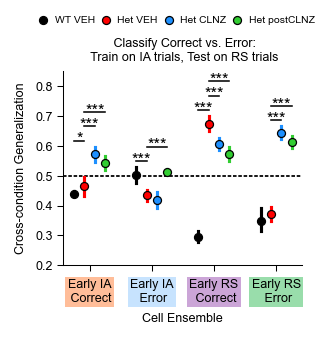

In [17]:
train_data = 'train_Early_IA_Correct_Early_IA_Error'
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
                                                             decode_out_distrib,
                                                             decoding_col = 'classes decoded',
                                                             decode_comp = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error',
                                                             enriched_group = 'enriched_group',
                                                             ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
                                                             posthoc_comparisons= preset_comparison_list, 
                                                             marker_params= geno_color_dict_no_errorbar,
                                                             ylim =[0.2, 0.85],   
                                                             verbose_titles= verbose_dicts[train_data],
                                                             scale = 1.)
add_xtick_color_boxes(ax_plot,['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_name = f"CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ {date_tag}"
save_plot_record_as_csv_txt(posthoc_df,"3",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png','svg'])

#### Figure 4B - CCGP for models trained on Correct (IA/RS) and tested on Error (IA/RS)

Saved 4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\25_Jan_2026' already exists.


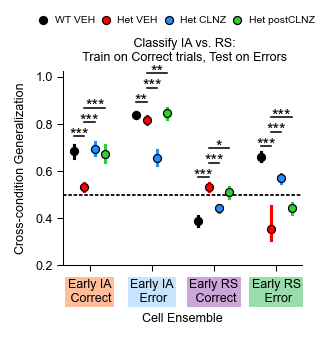

In [18]:
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,decode_out_distrib,
    decoding_col = 'classes decoded',
    decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error',
    enriched_group = 'enriched_group',
    ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'],
    posthoc_comparisons= preset_comparison_list,
    marker_params= geno_color_dict_no_errorbar,
    verbose_titles= verbose_dicts[train_data],scale = 1.)
##ax modifiers
add_xtick_color_boxes(ax_plot, ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error'], stage_palette_dict)
hand, labs =ax_plot.get_legend_handles_labels() 
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )
##save fig_posthoc 
fig_name = f"SVM generalize (early ens) train_correct_test_error accuracy"
save_plot_record_as_csv_txt(posthoc_df,"4",fig_name,csv_folder_most_recent, None, csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=4, filetypes_to_save = ['png','svg'])

## Plot the specific breakdown of classes predicted by CCG models

In [19]:
#cols to keep
confusion_mat_cols = ['true_pos','false_neg', 'false_pos', 'true_neg']
class_list = ['class_0_train','class_1_train','class_0_test','class_1_test']
run_ID_cols = ['geno_day','accuracy','pseudopop_run_num']

df = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].rename({'enriched_group':'ensemble'},axis = 1)
# df[confusion_mat_cols] = df[confusion_mat_cols].astype(int) / df['total'].values[:, None]  # Normalize to proportions
df.tail()

df[class_list] = df[class_list].astype(str)
# 3. Build all new columns w. vectorized string operations
df = df.assign(
    train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
    test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
    Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
    Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
)
confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
                   'Predict_class_0_train_x_Actual_class_1_test',
                   'Predict_class_1_train_x_Actual_class_0_test', 
                   'Predict_class_0_train_x_Actual_class_0_test']
grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])

df= grouped.reset_index().melt(value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'], id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names)
# 1. Define the mapping from your “variable” names to the Predict_… columns
col_map = {'true_pos':  'Predict_class_1_train_x_Actual_class_1_test','false_neg': 'Predict_class_0_train_x_Actual_class_1_test','false_pos': 'Predict_class_1_train_x_Actual_class_0_test','true_neg':  'Predict_class_0_train_x_Actual_class_0_test'}
df['var_column'] = df['variable'].map(col_map) #name of column containing var info
df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
input_df = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']].set_index(("train_on")).copy()
input_df.loc[:,'actual'] = input_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
input_df['value'] = input_df['value']*2
input_df.sample()

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_IA,Het VEH,0.4425,753,0.511563,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct,Early RS Error,Predict_class_0_train_x_Actual_class_1_test,false_neg


In [20]:
input_df

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.654687,0,0.906875,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.787344,0,0.912188,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.592031,0,0.675000,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.636406,0,0.724688,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.524375,0,0.493125,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.522969,999,0.340000,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.605000,999,1.000000,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.615000,999,0.986250,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [21]:
def plot_ccg_confusion_single_proportion(ax,
                                         input_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ('pi', 95),
                                         ylim=[0, 0.515],
                                         title_type = {'train_Early_IA_Correct_x_Early_RS_Correct':'Classification (IA vs. RS) of',
                                                       'train_Early_IA_Correct_x_Early_IA_Error': 'Classification (correct vs. error) of'},
                                         **kwargs):
    ''' started 6/25/25- To plot distributions of ccg''' 
    #modify df for better plot
    train_df = input_df.loc[train,:].reset_index()
    plot_df = train_df.loc[train_df.ensemble == ens,:].copy()
    plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
    #given you plot only one type, filter by type
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df['value'] = plot_df['value'] *100 #multiply by 100 to return percent
    stage_order = sorted(set(plot_df.loc[:,'actual']))
    plot_params = dict(data = plot_df,ax = ax,x = 'actual', y = 'value', dodge = 0.5, linestyles = 'none',order = stage_order,errorbar = errorbar, 
                       **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot])
    s = sns.pointplot(**plot_params)
    ###modify ax decorators
    set_pointplot_edgecolor(ax)
    ax_title = f"{title_type[train]}\n activity in {ens.replace('_', ' ')} ensemble"
    ylabel_options = {'train_Early_IA_Correct_x_Early_IA_Error': 'Correct',
                      'train_Early_IA_Correct_x_Early_RS_Correct':'RS'}
    set_labels(ax, label_dict = {'title':ax_title,
                                 'legend_false':True, 
                                 'xlabel':f"Test Data Stage",
                                 'ylim':ylim, 'ylabel': f"% Classified as {ylabel_options[train]}"})
    #run posthoc test 
    if "WT CLNZ" in plot_params['hue_order']: #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    # Draw canvas to ensure error bar coordinates are computed (fixes multi-subplot issue)
    ax.figure.canvas.draw()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.0175,offset_constant = 0.0085) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) 
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

#### Figure 3C: CCG model classifications of activity of Early RS Correct ensemble 

PathCollection indices: [3, 7, 11, 15]

=== bar_coords (error bar lines) ===
           child_x                                 child_y  y_is_2_elem
0    [-0.25, 0.75]                      [54.6515, 95.4735]         True
1   [-0.25, -0.25]  [51.87500000000001, 57.28515624999999]         True
2     [0.75, 0.75]                         [92.3125, 97.5]         True
3    [-0.08, 0.92]               [53.5403125, 18.62078125]         True
4   [-0.08, -0.08]                 [50.40625, 56.59765625]         True
5     [0.92, 0.92]              [13.187500000000002, 23.5]         True
6     [0.08, 1.08]               [65.6413125, 44.42115625]         True
7     [0.08, 0.08]                    [62.21875, 69.21875]         True
8     [1.08, 1.08]            [41.9375, 47.06249999999999]         True
9     [0.25, 1.25]              [77.29165625, 62.68184375]         True
10    [0.25, 0.25]                  [74.37109375, 80.1875]         True
11    [1.25, 1.25]        [59.08984375, 66.25000000000001] 

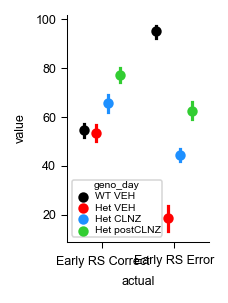

In [22]:
from matplotlib.collections import PathCollection as path_collection_type

# Create the plot
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize=ccg_uniprop_figsize, layout='tight')

# Reproduce plotting code from the function
train = 'train_Early_IA_Correct_x_Early_IA_Error'
train_df = input_df.loc[train,:].reset_index()
plot_df = train_df.loc[train_df.ensemble == ensemble,:].copy()
plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace('_', ' ')
prediction_class = "Predict_Early_IA_Correct"
plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
plot_df['value'] = plot_df['value'] * 100

stage_order = sorted(set(plot_df.loc[:,'actual']))
plot_params = dict(data=plot_df, ax=ax, x='actual', y='value', dodge=0.5, 
                   linestyles='none', order=stage_order, errorbar=('pi', 75),
                   **geno_color_dict_no_errorbar)
s = sns.pointplot(**plot_params)
ax.figure.canvas.draw()

# DEBUG: Inspect error bar detection
ax_childs = s.get_children()
ax_child_types = [type(x) for x in ax_childs]
ax_child_points_index = [count for count, x in enumerate(ax_child_types) if x is path_collection_type]
print(f"PathCollection indices: {ax_child_points_index}")

# Check what's in bar_coords
from plot_posthoc_test.plot_stat_annotate import return_ax_child_line_coor
bar_coords = return_ax_child_line_coor(ax_childs, ax_child_points_index)
bar_coords['y_is_nonnan'] = bar_coords.child_y.apply(lambda x: ~np.any(np.isnan(x)))
bar_coords['y_is_2_elem'] = bar_coords.child_y.apply(lambda x: x.size == 2)

print("\n=== bar_coords (error bar lines) ===")
print(bar_coords[['child_x', 'child_y', 'y_is_2_elem']].to_string())

# Check what coordinates posthoc_df expects to match
from plot_posthoc_test.plot_stat_annotate import get_hue_point_loc_df
hue_loc_df = get_hue_point_loc_df(ax, geno_order)
print("\n=== hue_loc_df (point positions) ===")
print(hue_loc_df)

In [23]:
# Debug: What Line2D objects exist?
lines = [x for x in ax.get_children() if isinstance(x, matplotlib.lines.Line2D)]
print(f"Total Line2D objects: {len(lines)}")

for i, line in enumerate(lines):
    xdata = line.get_xdata()
    ydata = line.get_ydata()
    print(f"Line {i}: x={np.round(xdata, 3)}, y={np.round(ydata, 3)}")

# Also check PathCollection (the actual points)
from matplotlib.collections import PathCollection
collections = [x for x in ax.get_children() if isinstance(x, PathCollection)]
print(f"\nTotal PathCollections: {len(collections)}")
for i, coll in enumerate(collections):
    offsets = coll.get_offsets()
    print(f"Collection {i}: offsets={offsets}")

Total Line2D objects: 12
Line 0: x=[-0.25  0.75], y=[54.652 95.474]
Line 1: x=[-0.25 -0.25], y=[51.875 57.285]
Line 2: x=[0.75 0.75], y=[92.312 97.5  ]
Line 3: x=[-0.083  0.917], y=[53.54  18.621]
Line 4: x=[-0.083 -0.083], y=[50.406 56.598]
Line 5: x=[0.917 0.917], y=[13.188 23.5  ]
Line 6: x=[0.083 1.083], y=[65.641 44.421]
Line 7: x=[0.083 0.083], y=[62.219 69.219]
Line 8: x=[1.083 1.083], y=[41.938 47.062]
Line 9: x=[0.25 1.25], y=[77.292 62.682]
Line 10: x=[0.25 0.25], y=[74.371 80.188]
Line 11: x=[1.25 1.25], y=[59.09 66.25]

Total PathCollections: 4
Collection 0: offsets=[[-0.25 54.6515]
 [0.75 95.4735]]
Collection 1: offsets=[[-0.08333333333333334 53.5403125]
 [0.9166666666666666 18.62078125]]
Collection 2: offsets=[[0.08333333333333331 65.6413125]
 [1.0833333333333333 44.42115625]]
Collection 3: offsets=[[0.25 77.29165625]
 [1.25 62.68184375]]


In [24]:
# Check the actual data being plotted
print("=== Data check ===")
print(f"plot_df['value'] stats: min={plot_df['value'].min()}, max={plot_df['value'].max()}, mean={plot_df['value'].mean()}")
print(f"\nFirst 5 rows:\n{plot_df[['actual', 'value', 'geno_day']].head()}")

# Check what the axes are showing
print(f"\n=== Axes limits ===")
print(f"ylim: {ax.get_ylim()}")
print(f"xlim: {ax.get_xlim()}")

# Check seaborn version
import seaborn as sns
print(f"\nSeaborn version: {sns.__version__}")

=== Data check ===
plot_df['value'] stats: min=5.84375, max=98.625, mean=59.892575

First 5 rows:
               actual     value      geno_day
30015  Early RS Error  47.40625      Het CLNZ
30016  Early RS Error  13.96875       Het VEH
30017  Early RS Error  64.06250  Het postCLNZ
30018  Early RS Error  47.31250       WT CLNZ
30019  Early RS Error  97.56250        WT VEH

=== Axes limits ===
ylim: (8.971875, 101.715625)
xlim: (-0.5, 1.5)

Seaborn version: 0.12.1


In [25]:
# Trace the data pipeline
train = 'train_Early_IA_Correct_x_Early_IA_Error'
ensemble = "Early_RS_Correct"
prediction_class = "Predict_Early_IA_Correct"

print("=== Step 1: input_df at train index ===")
train_df = input_df.loc[train,:].reset_index()
print(f"Shape: {train_df.shape}")
print(f"value stats: min={train_df['value'].min()}, max={train_df['value'].max()}")
print(f"Unique ensembles: {train_df['ensemble'].unique()}")

print("\n=== Step 2: Filter by ensemble ===")
ens_df = train_df.loc[train_df.ensemble == ensemble,:]
print(f"Shape after ensemble filter: {ens_df.shape}")
print(f"value stats: min={ens_df['value'].min()}, max={ens_df['value'].max()}")

print("\n=== Step 3: Filter by prediction_class ===")
pred_df = ens_df.loc[ens_df.predict == prediction_class,:]
print(f"Shape after predict filter: {pred_df.shape}")
print(f"value stats: min={pred_df['value'].min()}, max={pred_df['value'].max()}")
print(f"\nSample rows:\n{pred_df[['ensemble', 'predict', 'actual', 'value']].head(10)}")

=== Step 1: input_df at train index ===
Shape: (120000, 12)
value stats: min=0.0, max=1.0
Unique ensembles: ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']

=== Step 2: Filter by ensemble ===
Shape after ensemble filter: (20000, 12)
value stats: min=0.01375, max=0.98625

=== Step 3: Filter by prediction_class ===
Shape after predict filter: (10000, 12)
value stats: min=0.058437499999999996, max=0.98625

Sample rows:
               ensemble                   predict          actual     value
30015  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.474062
30016  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.139688
30017  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.640625
30018  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.473125
30019  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.975625
30045  Early_RS_Correct  Predict_Early_IA_Correct  Early RS Error  0.459688
3

In [26]:
# Check the source data
print("=== decode_out_distrib confusion matrix values ===")
print(decode_out_distrib[confusion_mat_cols].describe())

print("\n=== After normalization ===")
df_test = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + ['total'] + class_list].copy()
print(f"Before astype(int): {df_test[confusion_mat_cols].dtypes}")
print(f"Sample values before division:\n{df_test[confusion_mat_cols].head()}")
print(f"Sample total values: {df_test['total'].head().tolist()}")

# The potential issue - check what astype(int) does
df_test[confusion_mat_cols] = df_test[confusion_mat_cols].astype(int)
print(f"\nAfter astype(int):\n{df_test[confusion_mat_cols].head()}")

df_test[confusion_mat_cols] = df_test[confusion_mat_cols] / df_test['total'].values[:, None]
print(f"\nAfter division by total:\n{df_test[confusion_mat_cols].head()}")

=== decode_out_distrib confusion matrix values ===
            true_pos      false_neg      false_pos       true_neg
count  120000.000000  120000.000000  120000.000000  120000.000000
mean        0.254824       0.245176       0.212067       0.287933
std         0.117590       0.117590       0.110612       0.110612
min         0.000000       0.000000       0.000000       0.000000
25%         0.176719       0.171719       0.135781       0.209375
50%         0.257500       0.242500       0.221406       0.278594
75%         0.328281       0.323281       0.290625       0.364219
max         0.500000       0.500000       0.500000       0.500000

=== After normalization ===
Before astype(int): true_pos     float64
false_neg    float64
false_pos    float64
true_neg     float64
dtype: object
Sample values before division:
   true_pos  false_neg  false_pos  true_neg
0  0.453437   0.046562   0.298750  0.201250
1  0.456094   0.043906   0.168750  0.331250
2  0.337500   0.162500   0.245469  0.254531
3

Saved 3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_3\25_Jan_2026' already exists.


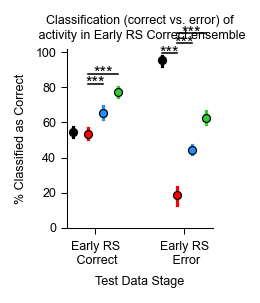

In [27]:
##Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'tight')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order,
                                                  prediction_class= "Predict_Early_IA_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, None],)
##savefig 
fig_num = 3
fig_name = f"CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix= "predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

In [28]:
posthoc_df

,category_compared_within,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_sem,group_2_mean,group_2_sem,test_name,...,g_2_child_x,g_2_child_y,max_group_loc_val,numeric_var,hue_var,x_category_var,hue_is_x_axis,date_tag,fig_name,fig_num
0,Early RS Error,WT VEH,Het VEH,"(1000,)","(1000,)",96.0260,1.1970,18.6113,2.8353,robust_cohen_d,...,"[0.92, 0.92]","[13.187500000000002, 23.5]",97.500000,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
1,Early RS Error,Het VEH,Het CLNZ,"(1000,)","(1000,)",18.6113,2.8353,44.4071,1.4531,robust_cohen_d,...,"[1.08, 1.08]","[41.9375, 47.06249999999999]",47.062500,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
2,Early RS Error,Het VEH,Het postCLNZ,"(1000,)","(1000,)",18.6113,2.8353,62.7580,1.9467,robust_cohen_d,...,"[1.25, 1.25]","[59.08984375, 66.25000000000001]",66.250000,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
3,Early RS Correct,WT VEH,Het VEH,"(1000,)","(1000,)",54.6671,1.5026,53.5409,1.7662,robust_cohen_d,...,"[-0.08, -0.08]","[50.40625, 56.59765625]",57.285156,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
4,Early RS Correct,Het VEH,Het CLNZ,"(1000,)","(1000,)",53.5409,1.7662,65.6807,1.9651,robust_cohen_d,...,"[0.08, 0.08]","[62.21875, 69.21875]",69.218750,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3
5,Early RS Correct,Het VEH,Het postCLNZ,"(1000,)","(1000,)",53.5409,1.7662,77.3558,1.6607,robust_cohen_d,...,"[0.25, 0.25]","[74.37109375, 80.1875]",80.187500,value,geno_day,actual,False,25_Jan_2026,CCG single class pred- Train IA test RS - Earl...,3


#### Figure 4C: % of samples classified as RS, for activity from Early IA Correct ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\25_Jan_2026' already exists.


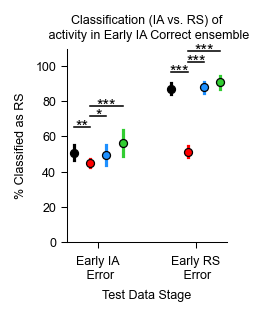

In [29]:
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order,
                                       prediction_class = "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 110])
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None,
                        csv_suffix="predict_posthoc cohen d",txt_suffix= "predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### Figure 4F: % of samples classified as RS, for activity from Early RS Error ensemble

Saved 4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_4\25_Jan_2026' already exists.


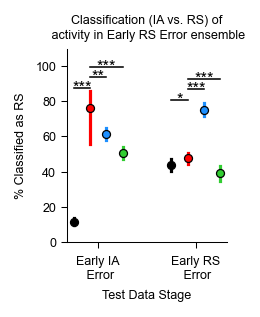

In [30]:
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax,input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name, csv_folder_most_recent, None, csv_suffix="predict_posthoc cohen d",txt_suffix="predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

#### supplement uniproportion CCG classes

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Jan_2026' already exists.


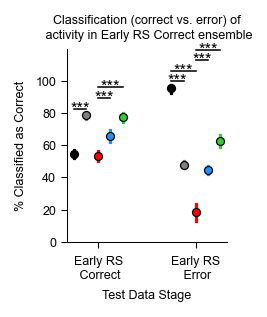

In [31]:
## SUPP Figure 3- TRAIN IA
ensemble = "Early_RS_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_IA_Error',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ,
                                       prediction_class= "Predict_Early_IA_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120],)
##savefig 
fig_num = 3
fig_name = f"supp_CCG single class pred- Train IA test RS - {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix=f"supp_predict_posthoc cohen d",txt_suffix=f"supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_2", filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Jan_2026' already exists.


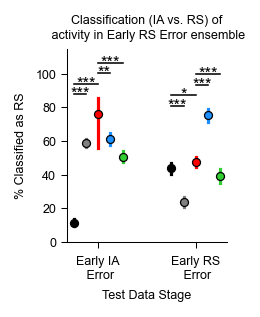

In [32]:
#SUPP FIGURE 4
ensemble = "Early_RS_Error"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                                  ens= ensemble,
                                                  genos_to_plot = geno_order_w_WT_CLNZ,
                                                  prediction_class= "Predict_Early_RS_Correct",
                                                  errorbar = ('pi', 75),ylim=[0, 115])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_CCG 1_class pred-Train_Correct_Test_Error-Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_25_Jan_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Jan_2026' already exists.


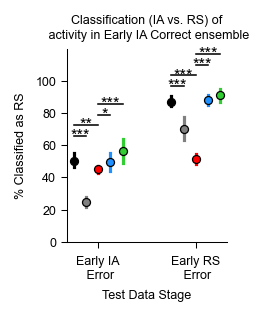

In [33]:
#FIGURE 4- IA Correct
ensemble = "Early_IA_Correct"
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = 'train_Early_IA_Correct_x_Early_RS_Correct',
                                       ens= ensemble,
                                       genos_to_plot = geno_order_w_WT_CLNZ, #specify if including WT CLNZ
                                       prediction_class= "Predict_Early_RS_Correct",
                                       errorbar = ('pi', 75), ylim=[0, 120])
##savefig 
fig_num = 4
fig_name = f"supp_CCG 1_class pred-Train_Correct_Test_Error-{ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,f"2_s",fig_name, csv_folder_most_recent, None,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_2', filetypes_to_save = ['png','svg'])

## Linear SVM Plots (Figures: 5-7 + S2)

In [34]:
def plot_decode_accuracy_ensemble_subset(pop_mean_decoding,
                                         decoding_col, 
                                         decoder_comparison, 
                                         ensemble_col,
                                         ax_plot,
                                         ensemble_subset=None, 
                                         ylim = [0.8, 1.05],
                                         plot_config = geno_color_dict_no_errorbar,
                                        **kwargs):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, for all ensemble groups ued for decoding. inputs: plot config- usually contains geno_color_dict/ describes default paleete info, etc ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    if ensemble_subset == None:
        ensemble_subset= pop_mean_decoding[ensemble_col].unique()
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison)&(pop_mean_decoding[ensemble_col].isin(ensemble_subset)) ,:]
    plot_params = {'data':plot_df, 'dodge': 0.35, 'markers': 'o',
                   'x': 'enriched_group', 'y':'accuracy', 'order':[x for x in phase_list_IA_RS_chrono if x in ensemble_subset ],
                   'errorbar': ('pi', 75), 'errwidth': 1.25, **plot_config}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    ## ax level changes
    verbose_decode = verbose_titles[decoder_comparison].replace("as", "as:\n").replace('_', ' ')
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)
    set_ax_title_xlabel_ylabel(ax_plot, {'title':f"Classify {verbose_decode}", 'ylim': ylim,
                                         'xlabel': "Cell Ensemble", 'ylabel': 'Mean accuracy', 'legend_false':False})#adjust plot information
    if "WT CLNZ" in plot_params['hue_order']:#Switch comparison list to use, if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, comparisons, test_name = 'cohen_d',detect_error_bar=True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True,tight_offset = 0.04,offset_constant = 0.01) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    ##format ax 
    # Draw canvas to ensure tick labels are computed (fixes multi-subplot timing issue)
    ax_plot.figure.canvas.draw()
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    add_xtick_color_boxes(ax_plot, ensemble_subset, stage_palette_dict)
    return posthoc_df

def plot_save_ensemble_svm_accuracy(decoding_df,
                                    decoder_comparison:str,
                                    ensemble_subset:list= [],
                                    decoding_col:str = 'classes decoded', 
                                    figsize =(1.65,2), 
                                    fig_layout = 'tight',
                                    bbox_to_anchor=(0.7, .975),
                                    ylim = [0.90,1.015],
                                    fig_name = None,
                                    fig_folder=5,
                                    figure_prefix= "",
                                    add_legend = False,
                                    **kwargs):
        
    fig, ax = plt.subplots(1,1, figsize =figsize, layout = fig_layout)
    posthoc_df = plot_decode_accuracy_ensemble_subset(decoding_df, decoding_col, 
                                                      decoder_comparison, 'enriched_group',
                                                      ax_plot = ax,
                                                      ensemble_subset= ensemble_subset,
                                                      ylim = ylim,
                                                      **kwargs)
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 1.0])
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() 
        fig.legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0, 'markerscale': 1, 'borderpad': 0.0, 'columnspacing': 0.0, 'handletextpad': 0.0})
    #save figs 
    if fig_name is None:
        fig_name = f"SVM classifier accuracy {decoder_comparison} by ensemble"
    fig_name =  "_".join([figure_prefix,fig_name])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_folder, filetypes_to_save = ['png', 'svg'])
    posthoc_df['plot_name'] = fig_name
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_folder}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc decode acc cohen D",txt_suffix="posthoc_text")
    return fig, ax,posthoc_df 


#### Figure 5C: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\25_Jan_2026' already exists.
Saved 5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\5_5C_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_25_Jan_2026.txt


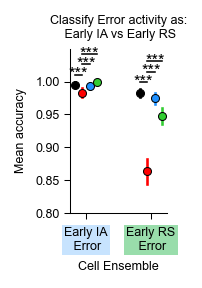

In [35]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'],ylim = [0.80,1.05], figsize = (1.25,1.90),fig_folder=5,  figure_prefix= "5C" )

#### Figure 5D: Time-based classification of Early IA Error vs Early RS Error, using Early RS Error ensemble data

In [36]:
def plot_ensemble_value_at_timebin(
    ax_plot, 
    timebin_values,
    ensemble,
    y_val,
    **kwargs):
    ''' Plot  time-bin bootstrapped metric for a given ensemble, for a given pair of classes to compare'''  

    plot_df = timebin_values.loc[timebin_values.enriched_group == ensemble,:].dropna()
    plot_df['bin_name'] = plot_df['bin_name'].str.replace(".0s to ", "-").str.replace(".0s", "").str.replace("--", "-")#rename bin
    plot_params = {'data': plot_df,  'x': 'bin_name', 'y' : y_val, 'errorbar': ('pi', 75), 'errwidth': 1.25, 'order': plot_df['bin_name'].unique(),
                  **kwargs, **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot, **plot_params,  )#make cosine sim plot itself
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)    # ax_plot.legend_.remove()
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, test_name = 'cohen_d',detect_error_bar = True)
    return posthoc_df

def plot_save_time_dep_decoding(
    decoding_df,
    decoding_col,
    decoding_metric = 'mean_acc',
    decoder_comparison = None,
    ensemble = None,
    ylim = [0.825,1.04],
    figsize = (1.75,1.75),
    fig_num=5,
    figure_prefix = "5D",
    use_verbose_title = True):
    ''' main script to plot time-dependent accuracy and save values ''' 
    verbose_decoded_pairs = ['IA activity as Early IA vs Early RS', 'Correct activity as Early IA vs Early RS', 'IA activity as Early IA vs Late IA','Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error', 'RS activity as Early RS vs Late', 'activity as Late IA vs Early RS Correct', 'Late activity as Late IA vs Late RS']
    verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,pop_mean_decoding['classes decoded'].unique().tolist())}
    verbose_titles
    fig, ax_plot = plt.subplots(1, 1, figsize = figsize, layout = 'constrained')
    
    time_decode_classes = decoding_df.loc[decoding_df[decoding_col] == decoder_comparison,:]
    posthoc_df = plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, decoding_metric, dodge = True)
    
    #for plotting titles
    decoder_comparison_clean = decoder_comparison.replace('_', ' ')
    ensemble_clean = ensemble.replace('_', ' ')
    if use_verbose_title:
        ax_title = f'{ensemble_clean} ensemble:\nClassify {verbose_titles[decoder_comparison]}'
    else:
        ax_title = f'{ensemble_clean} ensemble:\n Decoding {decoder_comparison_clean}'
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title, 'legend_false':True,'xlabel': f"Decoded time window (s)", 
    'xtick_rotation':  {'rotation':30}, 'ylabel': 'Decoding Accuracy'})
    ax_plot.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
    
    ##savefig
    fig_name = "_".join([figure_prefix, f'{ensemble_clean} ensemble time-based classification of {decoder_comparison_clean}'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=stage_to_fig[(decoder_comparison,ensemble)],  filetypes_to_save = ['png', 'svg'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_num}",
                                fig_name,
                                csv_folder_most_recent, None,
                                csv_suffix="posthoc acc cohen D",txt_suffix="posthoc_text")
    return fig, ax_plot,posthoc_df 

#### Supplementary Figure 2F: SVM accuracy classifying Errors as Early IA vs Early RS, using Early RS Error or Early IA Error Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Jan_2026' already exists.
Saved s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_F_SVM classifier accuracy Early_IA_Error_v_Early_RS_Error by ensemble_posthoc_text_25_Jan_2026.txt


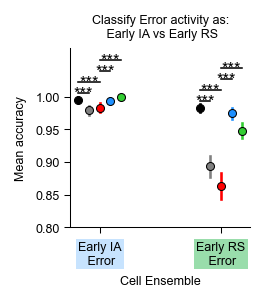

In [37]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Error_v_Early_RS_Error',
 ensemble_subset = ['Early_IA_Error', 'Early_RS_Error'], ylim = [0.82,1.075], figsize = supp_svm_panel_size,
 figure_prefix = "S2_F", fig_folder= 's_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Figure 6C: Early IA/RS Correct - SVM accuracy for Early RS Error Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\25_Jan_2026' already exists.
Saved 6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6C_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_25_Jan_2026.txt


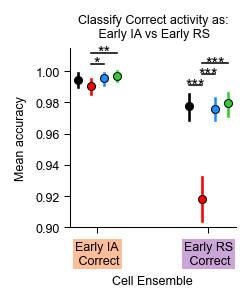

In [38]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct', 
    ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'],ylim = [0.9, 1.015], figure_prefix = "6C", fig_folder=6)

#### Figure 6D: Time-based classification of Correct as Early IA vs Early RS, using Early RS Correct ensemble data


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\25_Jan_2026' already exists.
Saved 6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\6_6D_Early RS Correct ensemble time-based classification of Early IA Correct v Early RS Correct_posthoc_text_25_Jan_2026.txt


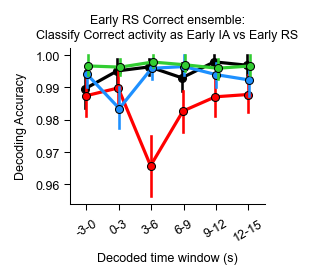

In [39]:
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col = "classes decoded", decoding_metric = 'accuracy', decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
    ensemble ='Early_RS_Correct', figsize = (1.75,1.75),figure_prefix = "6D", fig_num=6)

In [40]:

time_decode_scores

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,accuracy,bin_end_str,bin_default_size,timebin_size,run_end_time,dataset_folder_name,classes decoded,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.00000,-0.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.99625,3.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,1.00000,6.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,1.00000,9.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99875,12.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Early_IA_Correct_v_Early_IA_Error,9.0s to 12.0s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.90875,3.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,0.0s to 3.0s
143996,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.95875,6.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,3.0s to 6.0s
143997,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.94875,9.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,6.0s to 9.0s
143998,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.90375,12.0s,12,0.25,2026-01-23 10:37:43.483206,c:\Users\13car\Dropbox\local_github_repos_pers...,Late_IA_v_Early_RS_Correct,9.0s to 12.0s


#### Supplementary Figure 2H: SVM accuracy classifying Correct as Early IA vs Early RS, using Early IA or RS Correct Ensemble data (showing WT CLNZ)

switching posthoc comparison to include WT CLNZ
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Jan_2026' already exists.
Saved s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\s_2_S2_H_SVM classifier accuracy Early_IA_Correct_v_Early_RS_Correct by ensemble_posthoc_text_25_Jan_2026.txt


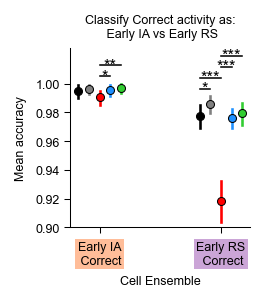

In [41]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct',
 ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct'], ylim = [0.9,1.025], figsize = supp_svm_panel_size,
  figure_prefix = "S2_H", fig_folder='s_2', plot_config = geno_order_w_WT_CLNZ_no_eb)

#### Figure 7C: SVM accuracy at classifying Early IA Correct vs. Late IA, using Early IA Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Jan_2026' already exists.
Saved 7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_C_SVM classifier accuracy Early_IA_Correct_v_Late_IA by ensemble_posthoc_text_25_Jan_2026.txt


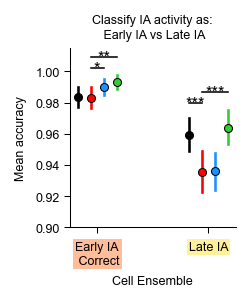

In [42]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Early_IA_Correct_v_Late_IA',
ensemble_subset = ['Early_IA_Correct', 'Late_IA'],figure_prefix = "7_C",fig_folder=7)

#### Figure 7G: SVM accuracy at classifying Early RS Correct vs. Late IA, using Early RS Correct/Late IA ensemble data

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Jan_2026' already exists.
Saved 7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc decode acc cohen D_25_Jan_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\7_7_G_SVM classifier accuracy Late_IA_v_Early_RS_Correct by ensemble_posthoc_text_25_Jan_2026.txt


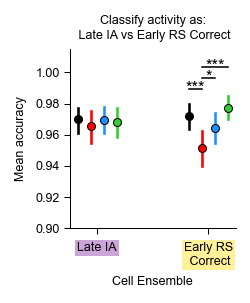

In [43]:
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding, decoder_comparison = 'Late_IA_v_Early_RS_Correct', 
    ensemble_subset = ['Early_RS_Correct', 'Late_IA'],figure_prefix = "7_G", fig_folder= 7)

## Summary Figure: All SVM Classifier Accuracy Plots

Combined view of all ensemble SVM accuracy comparisons from Figures 5, 6, 7, and Supplemental Figure 2.

{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Error_v_Early_RS_Error', 'ensemble_subset': ['Early_IA_Error', 'Early_RS_Error'], 'ylim': [0.8, 1.05], 'title': '5C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Early_RS_Correct', 'ensemble_subset': ['Early_IA_Correct', 'Early_RS_Correct'], 'ylim': [0.9, 1.015], 'title': '6C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_comparison': 'Early_IA_Correct_v_Late_IA', 'ensemble_subset': ['Early_IA_Correct', 'Late_IA'], 'ylim': [0.9, 1.015], 'title': '7C', 'plot_config': {'hue': 'geno_day', 'palette': ['black', 'red', 'dodgerblue', 'limegreen'], 'hue_order': ['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']}}
{'ax': <Axes: >, 'decoder_compa

Text(0.5, 0.98, 'Summary: SVM Classifier Accuracy by Ensemble')

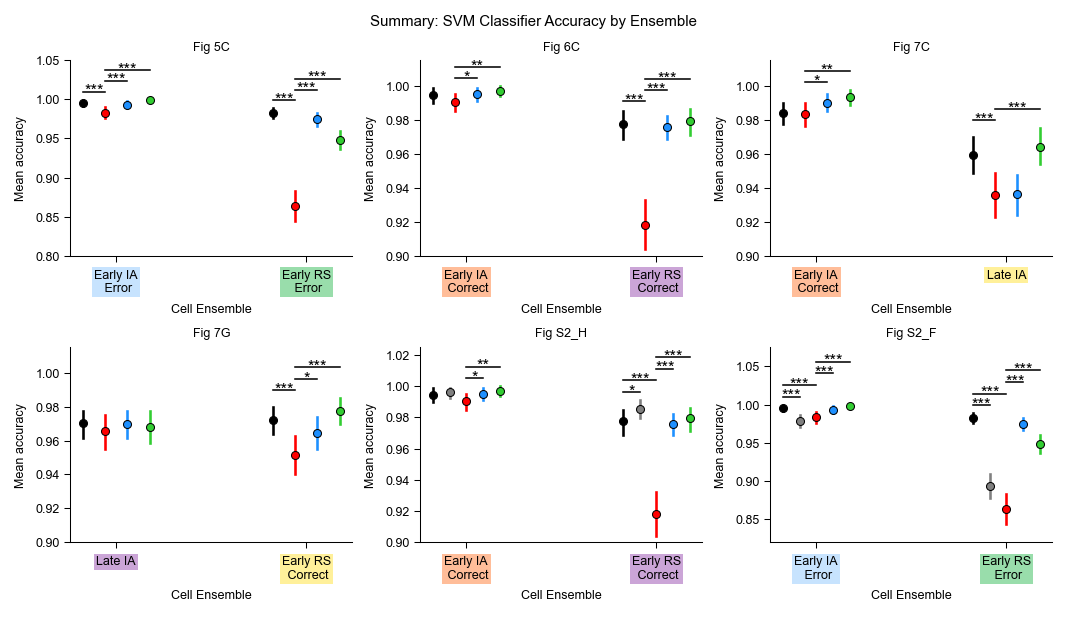

In [44]:
# Summary figure combining all SVM accuracy plots
fig, axes = plt.subplots(2, 3, figsize=(7, 4), layout="constrained")

# Define all plot configurations
plot_configs = [
    # Row 1
    {"ax": axes[0, 0], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.80, 1.05],
     "title": "5C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.015],
     "title": "6C", "plot_config": geno_color_dict_no_errorbar},
    {"ax": axes[0, 2], "decoder_comparison": "Early_IA_Correct_v_Late_IA",
     "ensemble_subset": ["Early_IA_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7C", "plot_config": geno_color_dict_no_errorbar},
     # Row 2
    {"ax": axes[1, 0], "decoder_comparison": "Late_IA_v_Early_RS_Correct",
     "ensemble_subset": ["Early_RS_Correct", "Late_IA"], "ylim": [0.90, 1.015],
     "title": "7G", "plot_config": geno_color_dict_no_errorbar},
     
     #supp 
     {"ax": axes[1, 1], "decoder_comparison": "Early_IA_Correct_v_Early_RS_Correct",
     "ensemble_subset": ["Early_IA_Correct", "Early_RS_Correct"], "ylim": [0.9, 1.025],
     "title": "S2_H", "plot_config": geno_order_w_WT_CLNZ_no_eb},
       {"ax": axes[1, 2], "decoder_comparison": "Early_IA_Error_v_Early_RS_Error",
     "ensemble_subset": ["Early_IA_Error", "Early_RS_Error"], "ylim": [0.82, 1.075],
     "title": "S2_F", "plot_config": geno_order_w_WT_CLNZ_no_eb},
]

# Generate each subplot
for config in plot_configs:
    print(config)
    plot_decode_accuracy_ensemble_subset(
        pop_mean_decoding,
        decoding_col="classes decoded",
        decoder_comparison=config["decoder_comparison"],
        ensemble_col="enriched_group",
        ax_plot=config["ax"],
        ensemble_subset=config["ensemble_subset"],
        ylim=config["ylim"],
        plot_config=config["plot_config"]
    )
    config["ax"].set_title(f"Fig {config['title']}", )

plt.suptitle("Summary: SVM Classifier Accuracy by Ensemble",)

# # Save the summary figure
# save_fig_in_main_fig_dir(fig, fig_name="Summary_SVM_classifier_accuracy_all_comparisons", 
#                         folder_key="1", filetypes_to_save=["png", "svg"])

## Compare Old vs New CCGP Results (Figures 3B & 4B)
Comparison of CCGP (Cross-Condition Generalization Performance) between:
- **Old**: `Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet`
- **New**: Most recent run from the decoding log

In [121]:
results_loc_ccg_compare = results_location / Path(f"CCG_comparison_{date_tag}")
make_folder(str(results_loc_ccg_compare))

The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\CCG_comparison_25_Jan_2026' has been created.


In [45]:
# Load old CCGP parquet file
old_CCG_filename = "Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet"
decode_out_distrib_old = pd.read_parquet(data_location / old_CCG_filename).rename(columns={"mean_acc": "accuracy"})

# Apply same column transformations as for the new data
decode_out_distrib_old['train_on'] = decode_out_distrib_old['class_0_train'].str.cat(decode_out_distrib_old['class_1_train'], sep="_").str.replace('_', ' ')
decode_out_distrib_old['test_on'] = decode_out_distrib_old['class_0_test'].str.cat(decode_out_distrib_old['class_1_test'], sep="_").str.replace('_', ' ')
decode_out_distrib_old['classes decoded'] = decode_out_distrib_old['train_on'].str.cat(decode_out_distrib_old['test_on'], sep=" v ")
decode_out_distrib_old['classes decoded'] = decode_out_distrib_old['classes decoded'].str.replace('_', ' ')
decode_out_distrib_old['total'] = decode_out_distrib_old['true_pos'] + decode_out_distrib_old['false_neg'] + decode_out_distrib_old['false_pos'] + decode_out_distrib_old['true_neg']

print(f"Loaded old CCGP data: {len(decode_out_distrib_old)} rows")
print(f"Current (new) CCGP data: {len(decode_out_distrib)} rows")
decode_out_distrib_old.head()

Loaded old CCGP data: 120000 rows
Current (new) CCGP data: 120000 rows


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,pseudopop_run_num,enriched_group,geno_day,...,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,classes decoded,total
0,0.691250,81.0,81.0,0.417031,0.274219,0.225781,0.082969,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.834392,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0
1,0.772344,81.0,63.0,0.454219,0.318125,0.181875,0.045781,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.895296,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Error Early RS Error,Early IA Correct Early RS Correct,Early IA Error Early RS Error v Early IA Corre...,1.0
2,0.569844,81.0,81.0,0.307500,0.262344,0.237656,0.192500,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.942382,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early IA Error,Early RS Correct Early RS Error,Early IA Correct Early IA Error v Early RS Cor...,1.0
3,0.651250,81.0,57.0,0.381406,0.269844,0.230156,0.118594,0,Early_IA_Correct,Het CLNZ,...,2025-05-31 16:06:16.989851,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early RS Correct Early RS Error,Early IA Correct Early IA Error,Early RS Correct Early RS Error v Early IA Cor...,1.0
4,0.560938,29.0,29.0,0.276719,0.284219,0.215781,0.223281,0,Early_IA_Correct,Het VEH,...,2025-05-31 16:06:17.055557,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...,1.0


### Figure 3B Comparison - CCGP for models Trained on IA, Tested on RS
Side-by-side comparison of old (May 2025) vs new CCGP results

### Figure 4B Comparison - CCGP for models trained on Correct, Tested on Error
Side-by-side comparison of old (May 2025) vs new CCGP results

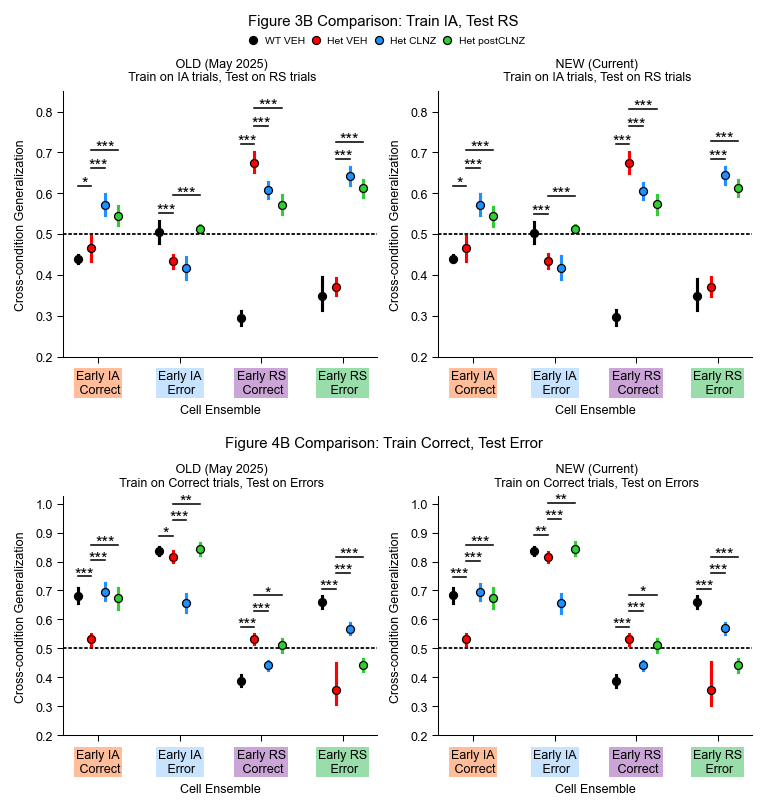

In [131]:
fig = plt.figure(figsize = (5,5), layout = 'constrained')
subfigs = fig.subfigures(2,1,)
axes = subfigs[0].subplots(1, 2)

# Figure 3B comparison: Train on IA, Test on RS
train_data = 'train_Early_IA_Correct_Early_IA_Error'
decode_comp_3b = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
ensembles_3b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# Old data (left)
posthoc_df_old_3b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib_old,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['OLD (May 2025)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[0], ensembles_3b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# New data (right)
posthoc_df_new_3b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_3b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_3b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 0.85], verbose_titles=['NEW (Current)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_3b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()
subfigs[0].legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False, title=None)
subfigs[0].suptitle('Figure 3B Comparison: Train IA, Test RS',y=1.1)

## Figure 4B comparison: Train on Correct (IA/RS), Test on Error (IA/RS)
axes = subfigs[1].subplots(1, 2)
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
decode_comp_4b = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
ensembles_4b = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# Old data (left)
posthoc_df_old_4b = plot_cross_condition_generalization_performance(
    axes[0], decode_out_distrib_old,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], scale=1.,
    verbose_titles=['OLD (May 2025)', verbose_dicts[train_data][1]])

add_xtick_color_boxes(axes[0], ensembles_4b, stage_palette_dict)
if axes[0].get_legend():
    axes[0].get_legend().remove()

# New data (right)
posthoc_df_new_4b = plot_cross_condition_generalization_performance(
    axes[1], decode_out_distrib,
    decoding_col='classes decoded', decode_comp=decode_comp_4b,
    enriched_group='enriched_group', ensembles_to_plot=ensembles_4b,
    posthoc_comparisons=preset_comparison_list, marker_params=geno_color_dict_no_errorbar,
    ylim=[0.2, 1.025], verbose_titles=['NEW (Current)', verbose_dicts[train_data][1]], scale=1.)
add_xtick_color_boxes(axes[1], ensembles_4b, stage_palette_dict)

# Shared legend
hand, labs = axes[1].get_legend_handles_labels()
if axes[1].get_legend():
    axes[1].get_legend().remove()# subfigs[1].legend(hand, labs, bbox_to_anchor=(0.5, 1.0), loc='lower center', ncols=4, frameon=False, title=None)
subfigs[1].suptitle('Figure 4B Comparison: Train Correct, Test Error')

## save combined subfigures into 1 figure
fig_name_3b = "Fig 3B CCG Train_IA Test_RS"
fig_name_4b = "Fig 4B Train_Correct Test_Error"
combined_fig_name = f"CCG_Compare_Fig3B_Fig4B_Paper_vs_New"
fig.savefig(results_loc_ccg_compare / f"{combined_fig_name}.png", dpi=300)

### Numeric Comparison Summary
Compare mean accuracy values between old and new CCGP results for each ensemble and decoding comparison

In [48]:
# Numeric comparison of old vs new CCGP accuracy - breakdown by geno_day and ensemble
def compare_ccgp_accuracy(df_old, df_new, decode_comp, ensembles, comparison_name):
    """Compare mean accuracy between old and new CCGP data, broken down by geno_day and ensemble."""
    results = []
    
    # Get all unique geno_days present in both datasets
    old_subset = df_old[df_old['classes decoded'] == decode_comp]
    new_subset = df_new[df_new['classes decoded'] == decode_comp]
    all_geno_days = sorted(set(old_subset['geno_day'].unique()) | set(new_subset['geno_day'].unique()))
    
    for geno_day in all_geno_days:
        for ens in ensembles:
            old_mask = (df_old['classes decoded'] == decode_comp) & (df_old['enriched_group'] == ens) & (df_old['geno_day'] == geno_day)
            new_mask = (df_new['classes decoded'] == decode_comp) & (df_new['enriched_group'] == ens) & (df_new['geno_day'] == geno_day)
            
            old_acc = df_old.loc[old_mask, 'accuracy']
            new_acc = df_new.loc[new_mask, 'accuracy']
            
            # Only add if there's data in at least one dataset
            if len(old_acc) > 0 or len(new_acc) > 0:
                old_mean = old_acc.mean() if len(old_acc) > 0 else np.nan
                new_mean = new_acc.mean() if len(new_acc) > 0 else np.nan
                diff = new_mean - old_mean if not (np.isnan(old_mean) or np.isnan(new_mean)) else np.nan
                
                results.append({
                    'Comparison': comparison_name,
                    'geno_day': geno_day,
                    'Ensemble': ens,
                    'Old Mean': old_mean,
                    'New Mean': new_mean,
                    'Difference': diff,
                    'Old N': len(old_acc),
                    'New N': len(new_acc)
                })
    return pd.DataFrame(results)

# Figure 3B comparison
comp_3b = compare_ccgp_accuracy(decode_out_distrib_old, decode_out_distrib, decode_comp_3b, ensembles_3b, 'Fig 3B (Train IA, Test RS)')

# Figure 4B comparison
comp_4b = compare_ccgp_accuracy(decode_out_distrib_old, decode_out_distrib, decode_comp_4b, ensembles_4b, 'Fig 4B (Train Correct, Test Error)')

# Combine and display
comparison_summary = pd.concat([comp_3b, comp_4b], ignore_index=True)
comparison_summary['Difference'] = comparison_summary['Difference'].apply(lambda x: f"{x:+.4f}" if pd.notna(x) else "N/A")
comparison_summary

,Comparison,geno_day,Ensemble,Old Mean,New Mean,Difference,Old N,New N
0,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_IA_Correct,0.571583,0.571274,-0.0003,1000,1000
1,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_IA_Error,0.417269,0.417334,+0.0001,1000,1000
2,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_RS_Correct,0.606837,0.606101,-0.0007,1000,1000
3,"Fig 3B (Train IA, Test RS)",Het CLNZ,Early_RS_Error,0.642864,0.643549,+0.0007,1000,1000
4,"Fig 3B (Train IA, Test RS)",Het VEH,Early_IA_Correct,0.465321,0.465586,+0.0003,1000,1000
5,"Fig 3B (Train IA, Test RS)",Het VEH,Early_IA_Error,0.432965,0.433706,+0.0007,1000,1000
6,"Fig 3B (Train IA, Test RS)",Het VEH,Early_RS_Correct,0.675171,0.674598,-0.0006,1000,1000
7,"Fig 3B (Train IA, Test RS)",Het VEH,Early_RS_Error,0.371494,0.371171,-0.0003,1000,1000
8,"Fig 3B (Train IA, Test RS)",Het postCLNZ,Early_IA_Correct,0.545007,0.543231,-0.0018,1000,1000
9,"Fig 3B (Train IA, Test RS)",Het postCLNZ,Early_IA_Error,0.513386,0.513180,-0.0002,1000,1000


### Investigate Potential Causes of Accuracy Differences
Two most likely causes for differences between old and new CCGP accuracy values:
1. **Different input trial timeseries data**: The parquet file used to build `class_matrix_store` may have changed (different preprocessing, different cells/trials included)
2. **Different decoding hyperparameters**: `num_resample`, `test_size`, `k_folds`, or `n_pseudopop_runs` may differ between runs

In [49]:
# Investigation 1: Check if the same geno_days (subjects) are present in both datasets
old_geno_days = set(decode_out_distrib_old['geno_day'].unique())
new_geno_days = set(decode_out_distrib['geno_day'].unique())

print("=== CAUSE 1: Different input trial timeseries data ===")
print(f"This would manifest as different subjects/geno_days being included")
print(f"Old dataset geno_days ({len(old_geno_days)}): {sorted(old_geno_days)}")
print(f"New dataset geno_days ({len(new_geno_days)}): {sorted(new_geno_days)}")
print(f"Only in OLD: {sorted(old_geno_days - new_geno_days)}")
print(f"Only in NEW: {sorted(new_geno_days - old_geno_days)}")
print(f"In BOTH: {len(old_geno_days & new_geno_days)} geno_days")

# Check total row counts per geno_day and enriched_group
print("--- Row counts per geno_day (summed across all comparisons) ---")
old_counts = decode_out_distrib_old.groupby('geno_day').size().rename('old_n_rows')
new_counts = decode_out_distrib.groupby('geno_day').size().rename('new_n_rows')
count_comparison = pd.concat([old_counts, new_counts], axis=1).fillna(0).astype(int)
count_comparison['diff'] = count_comparison['new_n_rows'] - count_comparison['old_n_rows']
print(count_comparison)

# Investigation 2: Check decoding run metadata if available
print("=== CAUSE 2: Different decoding hyperparameters ===")
print("Check the decoding run log for parameter differences:")
print("Key parameters: num_resample, test_size, k_folds, n_pseudopop_runs (n_iterations)")

# Try to get run info from the log
try:
    run_log_path = results_location / "decode_run_log.csv"
    if run_log_path.exists():
        run_log = pd.read_csv(run_log_path)
        ood_runs = run_log[run_log['decoding_type'] == 'out_of_distribution'].sort_values('run_end_time')
        print(f"Found {len(ood_runs)} out_of_distribution runs in log:")
        print(ood_runs[['run_date', 'run_end_time', 'run_dataset_used', 'n_iterations']].tail(5))
    else:
        print(f"Run log not found at {run_log_path}")
except Exception as e:
    print(f"Could not read run log: {e}")

# Compare column structure to detect any schema differences
print("=== Additional check: Column differences ===")
old_cols = set(decode_out_distrib_old.columns)
new_cols = set(decode_out_distrib.columns)
if old_cols != new_cols:
    print(f"Columns only in OLD: {old_cols - new_cols}")
    print(f"Columns only in NEW: {new_cols - old_cols}")
else:
    print("Both dataframes have identical column names")


=== CAUSE 1: Different input trial timeseries data ===
This would manifest as different subjects/geno_days being included
Old dataset geno_days (5): ['Het CLNZ', 'Het VEH', 'Het postCLNZ', 'WT CLNZ', 'WT VEH']
New dataset geno_days (5): ['Het CLNZ', 'Het VEH', 'Het postCLNZ', 'WT CLNZ', 'WT VEH']
Only in OLD: []
Only in NEW: []
In BOTH: 5 geno_days
--- Row counts per geno_day (summed across all comparisons) ---
              old_n_rows  new_n_rows  diff
geno_day                                  
Het CLNZ           24000       24000     0
Het VEH            24000       24000     0
Het postCLNZ       24000       24000     0
WT CLNZ            24000       24000     0
WT VEH             24000       24000     0
=== CAUSE 2: Different decoding hyperparameters ===
Check the decoding run log for parameter differences:
Key parameters: num_resample, test_size, k_folds, n_pseudopop_runs (n_iterations)
Run log not found at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\r

In [50]:
newest_raster = 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet'
old_raster = 'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet'

### Compare Input Trial Timeseries Data
Direct comparison of the underlying activity data used for decoding:
- **Old**: `Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet`
- **New**: `python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet`

Compare ensemble activity for each task stage to identify where the input data differs.

In [51]:
# Load both input timeseries parquet files
newest_raster_path = data_location / "python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet"
old_raster_path = data_location / "Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"

df_new = pd.read_parquet(newest_raster_path)
df_old = pd.read_parquet(old_raster_path)

print(f"Old dataset shape: {df_old.shape}")
print(f"New dataset shape: {df_new.shape}")

# Identify numeric activity columns (timeseries columns)
numeric_cols_old = [c for c in df_old.columns if ' to ' in c]
numeric_cols_new = [c for c in df_new.columns if ' to ' in c]

# Task stage column
stage_col = 'task_phase_vec'

# Ensemble columns (binary vectors indicating enrichment)
ensemble_cols = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']

# Figure 3B: Train IA, Test RS
train_stages_3b = ['Early_IA_Correct', 'Early_IA_Error']
test_stages_3b = ['Early_RS_Correct', 'Early_RS_Error']

# Figure 4B: Train Correct, Test Error  
train_stages_4b = ['Early_IA_Correct', 'Early_RS_Correct']
test_stages_4b = ['Early_IA_Error', 'Early_RS_Error']

def get_ensemble_activity_in_stages(df, numeric_cols, stage_col, ensemble_cols, activity_stages):
    """
    Get activity of cells enriched in each ensemble when in trials from activity_stages.
    ensemble_cols are binary columns indicating if a cell is enriched for that ensemble.
    """
    results = []
    for ens_col in ensemble_cols:
        # Filter to cells enriched in this ensemble
        ens_mask = df[ens_col] == 1
        
        for act_stage in activity_stages:
            # Filter to trials from this activity stage
            stage_mask = df[stage_col] == act_stage
            subset = df[ens_mask & stage_mask]
            
            if len(subset) > 0:
                mean_act = subset[numeric_cols].mean().mean()
                results.append({
                    'ensemble': ens_col,
                    'activity_stage': act_stage,
                    'mean_activity': mean_act,
                    'n_rows': len(subset)
                })
    return pd.DataFrame(results)

# Compare for Figure 3B stages
print("=== Figure 3B: Train on IA, Test on RS ===")
print("Ensemble activity in TRAIN stages (IA):")
ens_3b_train_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, train_stages_3b)
ens_3b_train_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, train_stages_3b)
comp_3b_train = ens_3b_train_old.merge(ens_3b_train_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_3b_train['mean_diff'] = comp_3b_train['mean_activity_new'] - comp_3b_train['mean_activity_old']
print(comp_3b_train)

print()
print("Ensemble activity in TEST stages (RS):")
ens_3b_test_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, test_stages_3b)
ens_3b_test_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, test_stages_3b)
comp_3b_test = ens_3b_test_old.merge(ens_3b_test_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_3b_test['mean_diff'] = comp_3b_test['mean_activity_new'] - comp_3b_test['mean_activity_old']
print(comp_3b_test)

print()
print("=== Figure 4B: Train on Correct, Test on Error ===")
print("Ensemble activity in TRAIN stages (Correct):")
ens_4b_train_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, train_stages_4b)
ens_4b_train_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, train_stages_4b)
comp_4b_train = ens_4b_train_old.merge(ens_4b_train_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_4b_train['mean_diff'] = comp_4b_train['mean_activity_new'] - comp_4b_train['mean_activity_old']
print(comp_4b_train)

print()
print("Ensemble activity in TEST stages (Error):")
ens_4b_test_old = get_ensemble_activity_in_stages(df_old, numeric_cols_old, stage_col, ensemble_cols, test_stages_4b)
ens_4b_test_new = get_ensemble_activity_in_stages(df_new, numeric_cols_new, stage_col, ensemble_cols, test_stages_4b)
comp_4b_test = ens_4b_test_old.merge(ens_4b_test_new, on=['ensemble', 'activity_stage'], suffixes=('_old', '_new'))
comp_4b_test['mean_diff'] = comp_4b_test['mean_activity_new'] - comp_4b_test['mean_activity_old']
print(comp_4b_test)

Old dataset shape: (93253, 93)
New dataset shape: (92731, 96)
=== Figure 3B: Train on IA, Test on RS ===
Ensemble activity in TRAIN stages (IA):
           ensemble    activity_stage  mean_activity_old  n_rows_old  \
0  Early_IA_Correct  Early_IA_Correct           0.142429        2296   
1  Early_IA_Correct    Early_IA_Error           0.060433         869   
2    Early_IA_Error  Early_IA_Correct           0.053015        1482   
3    Early_IA_Error    Early_IA_Error           0.176586         921   
4  Early_RS_Correct  Early_IA_Correct           0.075182        1159   
5  Early_RS_Correct    Early_IA_Error           0.051730         456   
6    Early_RS_Error  Early_IA_Correct           0.058362        1246   
7    Early_RS_Error    Early_IA_Error           0.055052         491   

   mean_activity_new  n_rows_new  mean_diff  
0           0.098243        2765  -0.044187  
1           0.059313        1018  -0.001121  
2           0.051575        1391  -0.001440  
3           0.127402  

### Compare Timeseries Values for Matching Cells
Check if the same unique cells have different activity timeseries values between the two dataframes.

In [52]:
# Different ID column names between dataframes
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'
trial_col = 'trial_num'
stage_col = 'task_phase_vec'

print(f"Old ID column: {id_col_old}, New ID column: {id_col_new}")

# Rename new df's ID column to match old for merging
df_new_renamed = df_new.rename(columns={id_col_new: id_col_old})

merge_cols = [id_col_old, trial_col, stage_col]
print(f"Matching on columns: {merge_cols}")

# Merge on identifiers to find matching rows
merged = df_old[merge_cols + numeric_cols_old].merge(
    df_new_renamed[merge_cols + numeric_cols_new],
    on=merge_cols,
    suffixes=('_old', '_new'),
    how='inner'
)
print(f"Matched rows: {len(merged)} (out of {len(df_old)} old, {len(df_new)} new)")

# Compare timeseries values for first numeric column as a sample
for col in numeric_cols_old:
    sample_col = col
    old_vals = merged[f"{sample_col}_old"]
    new_vals = merged[f"{sample_col}_new"]

    # Check if values are identical
    identical = (old_vals == new_vals).all()
    print(f"Values identical for '{sample_col}': {identical}")

    if not identical:
        # Check correlation
        corr = old_vals.corr(new_vals)
        print(f"Correlation between old and new: {corr:.4f}")
        
        # Check if it's a simple scaling
        ratio = (new_vals / old_vals.replace(0, np.nan)).dropna()
        print(f"Mean ratio (new/old): {ratio.mean():.4f}, Std: {ratio.std():.4f}")
        
        # Show sample of differences
        diff = new_vals - old_vals
        print(f"Difference stats:")
        print(f"  Mean diff: {diff.mean():.6f}")
        print(f"  Std diff: {diff.std():.6f}")
        print(f"  Min diff: {diff.min():.6f}")
        print(f"  Max diff: {diff.max():.6f}")
        
        # Sample a few rows to inspect
        print(f"Sample of matched rows (first 5):")
        sample_df = merged[[f"{sample_col}_old", f"{sample_col}_new"]].head()
        sample_df['diff'] = sample_df[f"{sample_col}_new"] - sample_df[f"{sample_col}_old"]
        print(sample_df)

Old ID column: unique_ID, New ID column: neuron_id
Matching on columns: ['unique_ID', 'trial_num', 'task_phase_vec']
Matched rows: 92731 (out of 93253 old, 92731 new)
Values identical for '-3.0s to -2.75s': True
Values identical for '-2.75s to -2.5s': True
Values identical for '-2.5s to -2.25s': True
Values identical for '-2.25s to -2.0s': True
Values identical for '-2.0s to -1.75s': True
Values identical for '-1.75s to -1.5s': True
Values identical for '-1.5s to -1.25s': True
Values identical for '-1.25s to -1.0s': True
Values identical for '-1.0s to -0.75s': True
Values identical for '-0.75s to -0.5s': True
Values identical for '-0.5s to -0.25s': True
Values identical for '-0.25s to -0.0s': True
Values identical for '0.0s to 0.25s': True
Values identical for '0.25s to 0.5s': True
Values identical for '0.5s to 0.75s': True
Values identical for '0.75s to 1.0s': True
Values identical for '1.0s to 1.25s': True
Values identical for '1.25s to 1.5s': True
Values identical for '1.5s to 1.75s

### Compare Enrichment Assignments Between Old and New
Check if the same cells have different ensemble enrichment status between datasets.

In [54]:
# Get enrichment status per cell (max across trials since it's constant per cell)
id_col_old = 'unique_ID'
id_col_new = 'neuron_id'

# Get unique cell enrichment from old
old_enrich = df_old.groupby(id_col_old)[ensemble_cols].max().reset_index()
old_enrich = old_enrich.rename(columns={col: f"{col}_old" for col in ensemble_cols})

# Get unique cell enrichment from new
new_enrich = df_new.groupby(id_col_new)[ensemble_cols].max().reset_index()
new_enrich = new_enrich.rename(columns={id_col_new: id_col_old})
new_enrich = new_enrich.rename(columns={col: f"{col}_new" for col in ensemble_cols})

# Merge on cell ID
enrich_comp = old_enrich.merge(new_enrich, on=id_col_old, how='inner')
print(f"Cells in both datasets: {len(enrich_comp)}")

# Check for differences in each ensemble
print()
print("=== Enrichment assignment differences ===")
for ens in ensemble_cols:
    old_col = f"{ens}_old"
    new_col = f"{ens}_new"
    
    # Count cells with different enrichment
    diff_mask = enrich_comp[old_col] != enrich_comp[new_col]
    n_diff = diff_mask.sum()
    
    # Breakdown: gained vs lost enrichment
    gained = ((enrich_comp[old_col] == 0) & (enrich_comp[new_col] == 1)).sum()
    lost = ((enrich_comp[old_col] == 1) & (enrich_comp[new_col] == 0)).sum()
    
    # Total enriched in each
    n_old = enrich_comp[old_col].sum()
    n_new = enrich_comp[new_col].sum()
    
    print(f"{ens}:")
    print(f"  Old: {int(n_old)} enriched, New: {int(n_new)} enriched")
    print(f"  Differences: {n_diff} cells (gained: {gained}, lost: {lost})")

# Overall summary
print()
print("=== Overall enrichment counts ===")
for ens in ensemble_cols:
    old_total = df_old.groupby(id_col_old)[ens].max().sum()
    new_total = df_new.groupby(id_col_new)[ens].max().sum()
    print(f"{ens}: Old={int(old_total)}, New={int(new_total)}, Diff={int(new_total - old_total)}")

# Show cells that changed enrichment status
print()
print("=== Cells with changed enrichment (first 20) ===")
any_diff = False
for ens in ensemble_cols:
    old_col = f"{ens}_old"
    new_col = f"{ens}_new"
    diff_mask = enrich_comp[old_col] != enrich_comp[new_col]
    if diff_mask.any():
        any_diff = True
        changed = enrich_comp[diff_mask][[id_col_old, old_col, new_col]].head(5)
        print(f"{ens} changes:")
        print(changed.to_string(index=False))
        print()

if not any_diff:
    print("No cells changed enrichment status between datasets")

Cells in both datasets: 4749

=== Enrichment assignment differences ===
Early_IA_Correct:
  Old: 626 enriched, New: 748 enriched
  Differences: 791 cells (gained: 422, lost: 295)
Early_IA_Error:
  Old: 478 enriched, New: 451 enriched
  Differences: 1386 cells (gained: 202, lost: 225)
Early_RS_Correct:
  Old: 320 enriched, New: 351 enriched
  Differences: 454 cells (gained: 207, lost: 173)
Early_RS_Error:
  Old: 345 enriched, New: 376 enriched
  Differences: 452 cells (gained: 207, lost: 171)

=== Overall enrichment counts ===
Early_IA_Correct: Old=628, New=748, Diff=120
Early_IA_Error: Old=479, New=451, Diff=-28
Early_RS_Correct: Old=320, New=351, Diff=31
Early_RS_Error: Old=345, New=376, Diff=31

=== Cells with changed enrichment (first 20) ===
Early_IA_Correct changes:
       unique_ID  Early_IA_Correct_old  Early_IA_Correct_new
10_3_HET_RS1-104                   0.0                   1.0
10_3_HET_RS1-122                   0.0                   1.0
10_3_HET_RS1-126                   

## Compare Weights between old and new

#### Import +plot weights from latest run

In [62]:
## check if cell Id is dropped for any fold within each group
def check_cell_ids(x):
    cell_ids_list = [set(ids) for ids in x]
    all_cells = set.union(*cell_ids_list)
    
    missing = {}
    for k, ids in enumerate(cell_ids_list):
        diff = all_cells - ids
        if diff:
            missing[k] = list(diff)
    
    return pd.Series({
        'cell_ids': np.array(list(all_cells)),  # Union of all cells
        'cells_consistent': len(missing) == 0,
        'missing_by_fold': missing if missing else None  # {fold: [missing_ids]}
    })

def extract_weight_matrices(df, group_cols=['bootstrap_run', 'ensemble', 'geno_day', 'train_on', 'test_on']):
        # Pre-sort once instead of per-group
    df = df.sort_values(group_cols + ['k_fold'])
    extract_df = df.groupby(group_cols, sort=False).agg(weight_matrix=('weights', lambda x: np.vstack(x.values)),
                                                         k_folds=('k_fold', list), 
                                                           n_folds=('k_fold', 'count'),
                                                           mean_weights=('weights', 'mean'),
                                                           dataset_label = ('dataset_label', 'first'),
                                                              run_end_date = ('run_end_date', 'first'),
                                                           ).reset_index()
    # Add cell_id checks
    cell_check = df.groupby(group_cols, sort=False)['cell_ids'].apply(check_cell_ids).unstack().reset_index()
    extract_df = extract_df.merge(cell_check, on=group_cols)
    return extract_df

## for groups with consistently ordered cell ids, align to common cells and note if some are dropped
def align_to_common_cells(g):
    ids_list = g['cell_ids'].tolist()
    common = set.intersection(*map(set, ids_list))
    
    # Just filter to common cells using first row's ordering
    first_ids = list(ids_list[0])
    keep_idx = [i for i, c in enumerate(first_ids) if c in common]
    
    return pd.Series({
        'weight_matrix_all_runs': np.vstack(g['mean_weights'].values)[:, keep_idx],
        'final_cell_ids': np.array([first_ids[i] for i in keep_idx]),
        'n_dropped': len(first_ids) - len(keep_idx),
    })

In [63]:
latest_runs['run_end_time'].astype(str).str.split(" ")

3    [2026-01-23, 10:39:14.478693]
4    [2026-01-23, 10:39:14.490694]
5    [2026-01-23, 10:39:14.491694]
Name: run_end_time, dtype: object

In [64]:
weight_dfs = get_matrix_of_run_record(latest_runs, decoding_type_to_var, col_to_extract= 'weight_file_saved')

# Unpack to standalone variables for convenience
# decode_weights = weight_dfs.get('decode_scores')
# time_weight = weight_dfs.get('time_decode_scores')
decode_out_weights = weight_dfs.get('decode_out_distrib')
decode_out_weights


extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\binary_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_23_Jan_2026.parquet
Loaded in_distribution from 2026-01-23 10:39:14.478693 (960000 rows) -> decode_scores
extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\out_distrib_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_23_Jan_2026.parquet
Loaded out_of_distribution from 2026-01-23 10:39:14.490694 (480000 rows) -> decode_out_distrib
extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_23_Jan_2026\timedep_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_23_Jan_2026.parquet
Loaded timebin_decoding from 2026-01-23

,decoder_key,weights,cell_ids,intercept,c0_train,c1_train,c0_test,c1_test,run_end_time,run_source_dataset,run_end_date,dataset_label
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.9034697, -0.40097472, -0.63654536, -0.3342...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.897901,"[0.17875000000000008, 0.15299999999999994, 0.1...","[0.0, 0.00375, 0.0, 0.038000000000000006, 0.02...","[0.002, 0.0, 0.12024999999999997, 0.1875000000...","[0.0, 0.003, 0.07625, 0.0, 0.0, 0.071, 0.14924...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.9279944, -0.4923147, -0.73498976, -0.22748...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.847330,"[0.17875000000000008, 0.15299999999999994, 0.1...","[0.0, 0.00375, 0.0, 0.038000000000000006, 0.02...","[0.002, 0.0, 0.12024999999999997, 0.1875000000...","[0.0, 0.003, 0.07625, 0.0, 0.0, 0.071, 0.14924...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.97538394, -0.5090031, -0.50761396, -0.1977...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.644064,"[0.17875000000000008, 0.15299999999999994, 0.1...","[0.0, 0.00375, 0.0, 0.038000000000000006, 0.02...","[0.002, 0.0, 0.12024999999999997, 0.1875000000...","[0.0, 0.003, 0.07625, 0.0, 0.0, 0.071, 0.14924...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
3,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.98393923, -0.6739114, -0.5760805, -0.30869...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.757875,"[0.17875000000000008, 0.15299999999999994, 0.1...","[0.0, 0.00375, 0.0, 0.038000000000000006, 0.02...","[0.002, 0.0, 0.12024999999999997, 0.1875000000...","[0.0, 0.003, 0.07625, 0.0, 0.0, 0.071, 0.14924...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
4,0_Early_IA_Correct_Het CLNZ_Early_IA_Error_Ear...,"[-0.6893349, -2.2774386e-05, -0.15476307, -1.2...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",0.241739,"[0.002, 0.0, 0.12024999999999997, 0.1875000000...","[0.0, 0.003, 0.07625, 0.0, 0.0, 0.071, 0.14924...","[0.17875000000000008, 0.15299999999999994, 0.1...","[0.0, 0.00375, 0.0, 0.038000000000000006, 0.02...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
...,...,...,...,...,...,...,...,...,...,...,...,...
47995,999_Late_RS_WT VEH_Early_IA_Correct_Early_IA_E...,"[-0.87511, 0.0, 0.0, 0.0, 1.9502196, 0.1037143...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.086744,"[0.01325, 0.0, 0.0, 0.0, 0.0, 0.05225, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.153, 0.0582499999999999...","[0.035750000000000004, 0.12349999999999993, 0....","[0.04050000000000001, 0.09474999999999995, 0.0...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
47996,999_Late_RS_WT VEH_Early_RS_Correct_Early_RS_E...,"[0.16309856, -0.23115818, 0.0, 0.0, 0.0, 0.0, ...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.011456,"[0.035750000000000004, 0.12349999999999993, 0....","[0.04050000000000001, 0.09474999999999995, 0.0...","[0.01325, 0.0, 0.0, 0.0, 0.0, 0.05225, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.153, 0.0582499999999999...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-23,Old Paper Ensembles
47997,999_Late_RS_WT VEH_Early_RS_Correct_Early_RS_E...,"[0.1407288, -0.20109601, 0.0, 0.0, 0.0, 0.0, 1...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.017207,"[0.035750000000000004, 0.12349999999999993, 0....","[0.04050000000000001, 0.09474999999999995, 0.0...","[0.01325, 0.0, 0.0, 0.0, 0.0, 0.05225, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.153, 0.0582499999999999...",2026-01-23 10:39:14.490694,c:\Users\13car\Dropbox\local_gith

In [65]:
early_stages = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']
late_stages = ['Late_IA', 'Late_RS']

In [66]:
#parse decoding weight keys
decode_out_weights = parse_decoder_key(df = decode_out_weights, stage_names=stage_names, geno_order=geno_order_w_WT_CLNZ)
group_cols=['ensemble', 'geno_day', 'train_on', 'test_on', 'dataset_label', 'run_end_date']
## extract and concat weight matrices
weight_matrices = extract_weight_matrices(decode_out_weights)
stacked_weights = weight_matrices.groupby(group_cols, sort=False).apply(align_to_common_cells).reset_index()

## average weights over all bootstrap iters
stacked_weights['avg_weight_vector'] = stacked_weights['weight_matrix_all_runs'].apply(lambda x: x.mean(axis=0))
stacked_weights

,ensemble,geno_day,train_on,test_on,dataset_label,run_end_date,weight_matrix_all_runs,final_cell_ids,n_dropped,avg_weight_vector
0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-23,"[[-0.63758826, -0.46444258, -0.11161629, 0.083...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0,"[-0.63181335, -0.63402146, -0.021651017, 0.068..."
1,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,Old Paper Ensembles,2026-01-23,"[[-0.9476968, -0.51905096, -0.6138074, -0.2670...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0,"[-0.73686016, -0.5163245, -0.6557694, -0.16123..."
2,Early_IA_Correct,Het CLNZ,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,Old Paper Ensembles,2026-01-23,"[[-0.6287295, -8.043782e-05, -0.13125435, -1.2...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0,"[-0.3778835, 0.3136802, -0.24006481, -1.250205..."
3,Early_IA_Correct,Het CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Old Paper Ensembles,2026-01-23,"[[0.0, -0.62078875, 0.905558, -1.0626768, -1.3...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0,"[0.0, 0.13273911, 1.2233069, -1.0619175, -1.38..."
4,Early_IA_Correct,Het VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-23,"[[0.115950614, 0.30777907, -0.12066288, 0.0474...","[13_3_HET_RS1-136, 13_5_HET_RS1-39, 13_3_HET_R...",0,"[0.050778523, 0.120697156, -0.17967564, 0.0105..."
...,...,...,...,...,...,...,...,...,...,...
115,Late_RS,WT CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Old Paper Ensembles,2026-01-23,"[[0.0, -1.3998022, -0.20739646, -1.1941457, 0....","[7_5_WT_RS2-82, 7_5_WT_RS2-130, 13_6_WT_RS2-21...",0,"[0.0, -1.4297991, -0.17718624, -1.2375815, 0.0..."
116,Late_RS,WT VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-23,"[[-0.89777255, 0.0, 0.0, 0.0, 2.7024937, -0.06...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0,"[-0.9131452, 0.0, 0.0, 0.0, 2.1311142, 0.00742..."
117,Late_RS,WT VEH,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,Old Paper Ensembles,2026-01-23,"[[0.7970779, 2.8433478, 0.0, 0.0, 0.0, -1.9123...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0,"[0.63104314, 2.9989274, 0.0, 0.0, 0.0, -1.8283..."
118,Late_RS,WT VEH,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,Old Paper Ensembles,2026-01-23,"[[2.0660183, 2.6055253, 0.0, 0.0, -2.2956445, ...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0,"[1.9496757, 2.7505023, 0.0, 0.0, -1.8601851, -..."


In [67]:
weight_matrices

,bootstrap_run,ensemble,geno_day,train_on,test_on,weight_matrix,k_folds,n_folds,mean_weights,dataset_label,run_end_date,cell_ids,cells_consistent,missing_by_fold
0,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,"[[-0.6404037, -0.49813378, -0.10218027, 0.1074...","[0, 1, 2, 3]",4,"[-0.63758826, -0.46444258, -0.11161629, 0.0837...",Old Paper Ensembles,2026-01-23,"[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",True,None
1,0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,"[[-0.9034697, -0.40097472, -0.63654536, -0.334...","[0, 1, 2, 3]",4,"[-0.9476968, -0.51905096, -0.6138074, -0.26703...",Old Paper Ensembles,2026-01-23,"[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",True,None
2,0,Early_IA_Correct,Het CLNZ,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,"[[-0.6893349, -2.2774386e-05, -0.15476307, -1....","[0, 1, 2, 3]",4,"[-0.6287295, -8.043782e-05, -0.13125435, -1.25...",Old Paper Ensembles,2026-01-23,"[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",True,None
3,0,Early_IA_Correct,Het CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,"[[0.0, -0.0008744078, 0.9071566, -1.0812104, -...","[0, 1, 2, 3]",4,"[0.0, -0.62078875, 0.905558, -1.0626768, -1.32...",Old Paper Ensembles,2026-01-23,"[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",True,None
4,0,Early_IA_Correct,Het VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,"[[0.07126658, 0.2650984, -0.16411562, 0.100081...","[0, 1, 2, 3]",4,"[0.115950614, 0.30777907, -0.12066288, 0.04743...",Old Paper Ensembles,2026-01-23,"[13_3_HET_RS1-136, 13_5_HET_RS1-39, 13_3_HET_R...",True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,999,Late_RS,WT CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,"[[0.0, -1.7340788, -0.25473616, -1.1226904, 0....","[0, 1, 2, 3]",4,"[0.0, -1.6653979, -0.17226422, -1.3134336, 0.0...",Old Paper Ensembles,2026-01-23,"[7_5_WT_RS2-82, 7_5_WT_RS2-130, 13_6_WT_RS2-21...",True,None
119996,999,Late_RS,WT VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,"[[-0.9009148, 0.0, 0.0, 0.0, 1.3416715, -0.066...","[0, 1, 2, 3]",4,"[-0.88652235, 0.0, 0.0, 0.0, 1.8393989, 0.0593...",Old Paper Ensembles,2026-01-23,"[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",True,None
119997,999,Late_RS,WT VEH,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,"[[0.7482009, 2.8844821, 0.0, 0.0, 0.0, -1.6859...","[0, 1, 2, 3]",4,"[0.67749095, 2.7504542, 0.0, 0.0, 0.0, -1.7102...",Old Paper Ensembles,2026-01-23,"[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",True,None
119998,999,Late_RS,WT VEH,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,"[[2.0157828, 2.5569642, 0.0, 0.0, -1.212315, -...","[0, 1, 2, 3]",4,"[2.0150688, 2.5945158, 0.0, 0.0, -1.515344, -1...",Old Paper Ensembles,2026-01-23,"[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",True,None


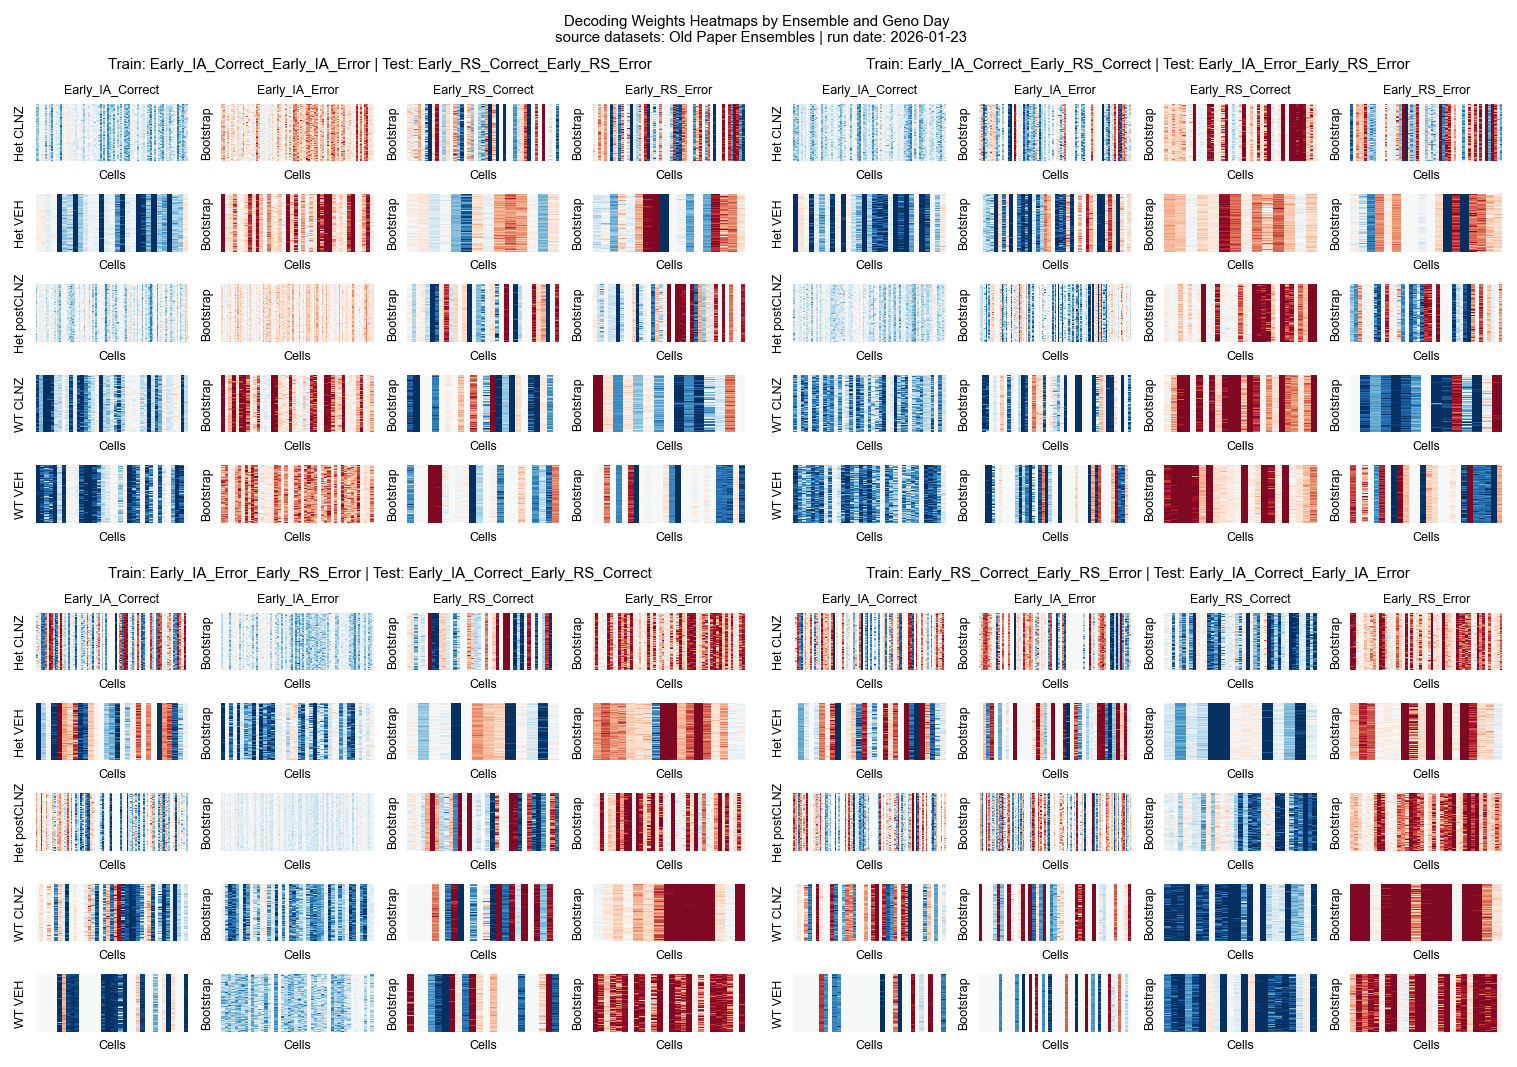

In [127]:
# figs = plot_weight_heatmaps(stacked_weights)

df = stacked_weights
all_weights = np.concatenate([m.flatten() for m in df['weight_matrix_all_runs']])
vmin, vmax = np.percentile(all_weights, [5, 95])
row='geno_day'
col='ensemble'

fig = plt.figure(figsize=(10, 7), layout='constrained')
subfigs = fig.subfigures(2,2,)
for comp_n, ((train_on, test_on), subset) in enumerate(df.groupby(['train_on', 'test_on'])):
    row_vals, col_vals = subset[row].unique(), subset[col].unique()
    subf = subfigs[comp_n//2, comp_n%2]
    axes = subf.subplots(len(row_vals), len(early_stages), squeeze=True)
    
    for (rv, ens), ax in zip(product(row_vals, early_stages), axes.flat):
        cell = subset[(subset[row] == rv) & (subset[col] == ens)]
        if  ens in early_stages and len(cell) > 0:
            last_col = ens == col_vals[-1]
            #use cell id + weight matrix to make table
            cell_weight_df = pd.DataFrame(cell['weight_matrix_all_runs'].iloc[0], columns=cell['final_cell_ids'].iloc[0])
            sns.heatmap(cell_weight_df, ax=ax, cmap='RdBu_r', center=0, vmin=vmin, vmax=vmax, cbar=True if last_col else False)
            set_labels(ax = ax, label_dict= {'title': f"{ens}" if rv == row_vals[0] else "", 
                                            'ylabel': rv if ens == col_vals[0] else "Bootstrap", 
                                            'xlabel': "Cells"})
            ax.set_xticks([])
            ax.set_yticks([])
    subf.suptitle(f"Train: {train_on} | Test: {test_on}")   

fig_suptitle = f"Decoding Weights Heatmaps by Ensemble and Geno Day \n source datasets: {weight_matrices.dataset_label.iloc[0]} | run date: {weight_matrices.run_end_date.iloc[0]}"
fig.suptitle(fig_suptitle)
##save fig
fig_filename = f"CCGP Decoding Weights by Ens X Geno Day _ SVM data {weight_matrices.dataset_label.iloc[0]} {date_tag}"
fig.savefig(results_loc_ccg_compare / f"{fig_filename}.png", dpi=300)

#### import weights from old run of interest

In [71]:
old_run_record_loc = r"C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_21_Jan_2026"
generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
#collect info on current runs to read them into notebook
old_run_info = pd.read_csv(old_run_record_loc + '/' + generalize_svm_record_file)

# get info on latest run record for out of distribution decoding
latest_runs_old = old_run_info.sort_values('run_end_time').groupby('decoding_type', sort=False).tail(1)
latest_runs_old

,Unnamed: 0,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,weight_file_saved
3,0,21_Jan_2026,in_distribution,2026-01-21 18:28:15.293593,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...
4,1,21_Jan_2026,out_of_distribution,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...
5,2,21_Jan_2026,timebin_decoding,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,C:\Users\13car\Dropbox\local_github_repos_pers...


In [72]:
old_weight_dfs = get_matrix_of_run_record(latest_runs_old, decoding_type_to_var, col_to_extract= 'weight_file_saved')
# Unpack to standalone variables for convenience # decode_weights = weight_dfs.get('decode_scores') # time_weight = weight_dfs.get('time_decode_scores')
old_decode_out_weights = old_weight_dfs.get('decode_out_distrib')
old_decode_out_weights

extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_21_Jan_2026\binary_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_21_Jan_2026.parquet
Loaded in_distribution from 2026-01-21 18:28:15.293593 (960000 rows) -> decode_scores
extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_21_Jan_2026\out_distrib_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_21_Jan_2026.parquet
Loaded out_of_distribution from 2026-01-21 18:28:15.313134 (480000 rows) -> decode_out_distrib
extracted filepath in weight_file_saved: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_21_Jan_2026\timedep_SVM_weights_enrich_unit_1000_pseudopop_post_outcome_activity_21_Jan_2026.parquet
Loaded timebin_decoding from 2026-01-21

,decoder_key,weights,cell_ids,intercept,run_end_time,run_source_dataset,run_end_date,dataset_label
0,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.8276172, -0.49674666, -0.7845844, -0.17416...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.591118,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
1,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.91007364, -0.69866085, -0.6957757, -0.2234...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.622897,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
2,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-0.39854777, -0.6331192, -0.67247266, -0.2705...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.555838,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
3,0_Early_IA_Correct_Het CLNZ_Early_IA_Correct_E...,"[-1.1114453, -0.6177794, -0.7454631, -0.309284...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",1.656310,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
4,0_Early_IA_Correct_Het CLNZ_Early_IA_Error_Ear...,"[-0.660106, 0.00084722374, -0.40229952, -1.372...","[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...",-0.058627,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
...,...,...,...,...,...,...,...,...
47995,999_Late_RS_WT VEH_Early_IA_Correct_Early_IA_E...,"[-0.89157486, 0.0, 0.0, 0.0, 1.3497854, 0.0952...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.084129,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
47996,999_Late_RS_WT VEH_Early_RS_Correct_Early_RS_E...,"[-0.2008786, -0.17859273, 0.0, 0.0, 0.0, 0.0, ...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.017636,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
47997,999_Late_RS_WT VEH_Early_RS_Correct_Early_RS_E...,"[0.1340707, -0.25359067, 0.0, 0.0, 0.0, 0.0, 1...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.016227,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles
47998,999_Late_RS_WT VEH_Early_RS_Correct_Early_RS_E...,"[0.0137350075, -0.20357673, 0.0, 0.0, 0.0, 0.0...","[5_3_WT_RS1-134, 5_3_WT_RS1-151, 6_2_WT_RS1-63...",-0.019234,2026-01-21 18:28:15.313134,c:\Users\13car\Dropbox\local_github_repos_pers...,2026-01-21,Old Paper Ensembles


In [80]:
# old_decode_filename = latest_runs_old[latest_runs_old['decoding_type'] == 'out_of_distribution']['weight_file_saved'].values[0]
# old_decode_out_weights = pd.read_parquet(old_decode_filename)
# old_decode_out_weights['run_end_time'] = old_decode_filename.split('activity_')[1].replace('.parquet', '')
# old_decode_out_weights
#parse decoding weight keys
old_decode_out_weights = parse_decoder_key(df = old_decode_out_weights, stage_names=stage_names, geno_order=geno_order_w_WT_CLNZ)
group_cols=['ensemble', 'geno_day', 'train_on', 'test_on', 'dataset_label', 'run_end_date']
## extract and concat weight matrices
weight_matrices_old = extract_weight_matrices(old_decode_out_weights)
stacked_weights_old = weight_matrices_old.groupby(group_cols, sort=False).apply(align_to_common_cells).reset_index()
stacked_weights_old

,ensemble,geno_day,train_on,test_on,dataset_label,run_end_date,weight_matrix_all_runs,final_cell_ids,n_dropped
0,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-21,"[[-0.98431516, -0.3364677, -0.15581243, 0.1553...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0
1,Early_IA_Correct,Het CLNZ,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,Old Paper Ensembles,2026-01-21,"[[-0.811921, -0.61157656, -0.72457397, -0.2443...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0
2,Early_IA_Correct,Het CLNZ,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,Old Paper Ensembles,2026-01-21,"[[-0.37831074, 0.0010131462, -0.37020013, -1.1...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0
3,Early_IA_Correct,Het CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Old Paper Ensembles,2026-01-21,"[[0.0, 0.20421568, 1.1484753, -1.0280648, -1.6...","[13_8_HET_RS2-127, 9_3_HET_RS2-131, 13_8_HET_R...",0
4,Early_IA_Correct,Het VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-21,"[[0.08787663, 0.11612896, -0.24645817, 0.03092...","[13_3_HET_RS1-136, 13_5_HET_RS1-39, 13_3_HET_R...",0
...,...,...,...,...,...,...,...,...,...
115,Late_RS,WT CLNZ,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Old Paper Ensembles,2026-01-21,"[[0.0, -1.4969321, -0.08146717, -1.1381685, 0....","[7_5_WT_RS2-82, 7_5_WT_RS2-130, 13_6_WT_RS2-21...",0
116,Late_RS,WT VEH,Early_IA_Correct_Early_IA_Error,Early_RS_Correct_Early_RS_Error,Old Paper Ensembles,2026-01-21,"[[-0.9897602, 0.0, 0.0, 0.0, 2.030357, 0.19211...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0
117,Late_RS,WT VEH,Early_IA_Correct_Early_RS_Correct,Early_IA_Error_Early_RS_Error,Old Paper Ensembles,2026-01-21,"[[0.5532769, 2.6862624, 0.0, 0.0, 0.0, -1.8220...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0
118,Late_RS,WT VEH,Early_IA_Error_Early_RS_Error,Early_IA_Correct_Early_RS_Correct,Old Paper Ensembles,2026-01-21,"[[2.006183, 2.7341642, 0.0, 0.0, -1.8361335, -...","[6_2_WT_RS1-63, 7_5_WT_RS1-143, 5_3_WT_RS1-134...",0


#### calculate weight cosine sim between old & new

In [75]:
from numpy.linalg import norm

def cosine_sim(x,y):
    norm_x, norm_y = norm(x), norm(y)
    if norm_x == 0 or norm_y == 0:
        return np.nan  # or return 0.0 if you prefer
    return np.dot(x, y) / (norm_x * norm_y)


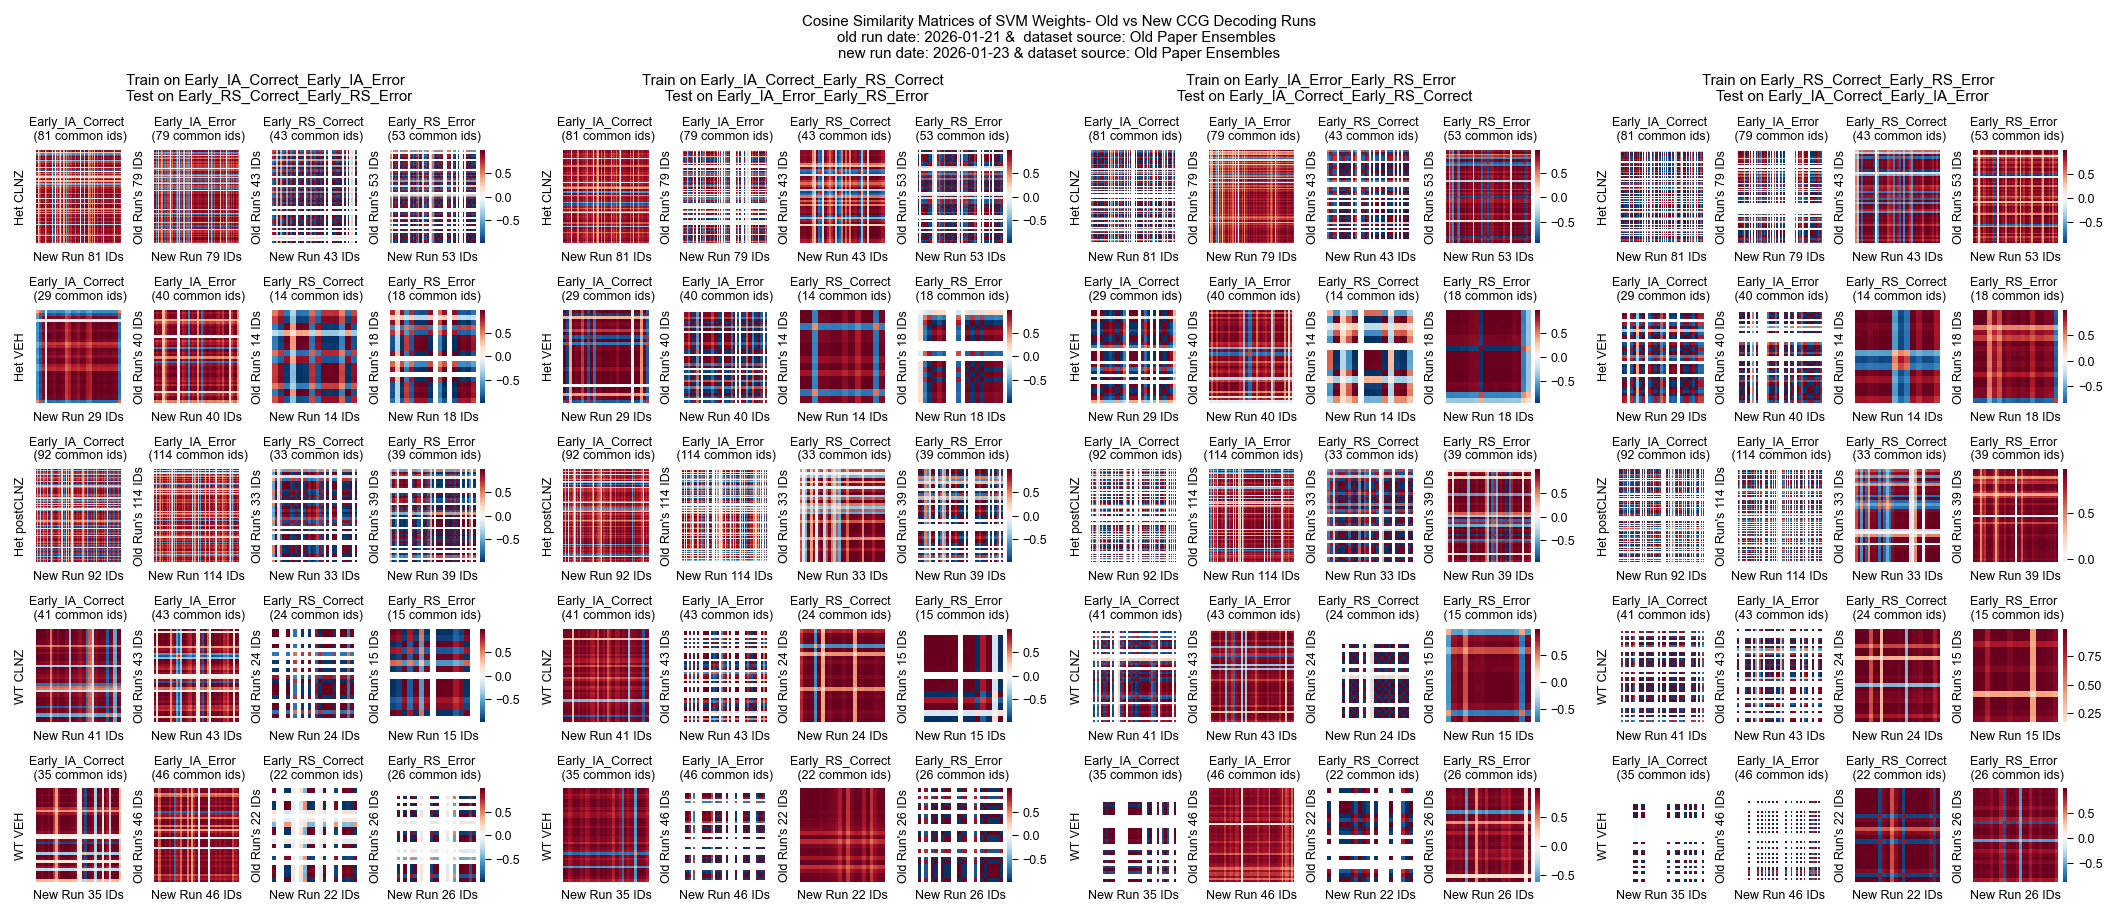

In [132]:
df = stacked_weights
vmin, vmax = [None, None]
row='geno_day'
col='ensemble'

#make figure w subfigs nested:
fig = plt.figure(figsize=(14, 6), layout='constrained')
subfigs = fig.subfigures(1,4)
corr_cell_dict = {}
for subfig_n, ((train_on, test_on), subset) in enumerate(df.groupby(['train_on', 'test_on'])):
    row_vals, col_vals = subset[row].unique(), early_stages
    corr_cell_dict[(train_on, test_on)]= {}
    subf = subfigs[subfig_n]
    axes = subf.subplots(len(row_vals), len(col_vals), squeeze=False)
    
    for (geno, ens), ax in zip(product(row_vals, col_vals), axes.flat):
        cell_new = subset[(subset[row] == geno) & (subset[col] == ens)]
        cell_old = stacked_weights_old[(stacked_weights_old[row] == geno) & (stacked_weights_old[col] == ens) & (stacked_weights_old['train_on'] == train_on) & (stacked_weights_old['test_on'] == test_on)]
        corr_cell_dict[(train_on, test_on)][(geno, ens)] = {}

        if len(cell_new):
            last_col = ens == col_vals[-1]
            #use cell id + weight matrix to make table
            cell_weight_df = pd.DataFrame(cell_new['weight_matrix_all_runs'].iloc[0],
                                          columns=cell_new['final_cell_ids'].iloc[0])
            #make old weight df aligned to new cell ids
            cell_old_weight_df = pd.DataFrame(cell_old['weight_matrix_all_runs'].iloc[0],
                                              columns=cell_old['final_cell_ids'].iloc[0])
            #get correlation of old and new weight dfs
            # 2. RENAME HERE - before merge
            cell_weight_df.columns = [str(c) + '_new' for c in cell_weight_df.columns]
            cell_old_weight_df.columns = [str(c) + '_old' for c in cell_old_weight_df.columns]
            # 3. Merge (suffixes param is redundant since you already renamed)
            merged_cells = pd.merge(cell_weight_df, cell_old_weight_df, left_index=True, right_index=True, suffixes=('_new', '_old'))
            corr_merged_df = merged_cells.corr(method = cosine_sim)

            # 4. Get column names (already have suffixes)
            old_cell_ids = cell_old_weight_df.columns   # ['cellA_old', 'cellB_old', ...]
            new_cell_ids = cell_weight_df.columns       # ['cellA_new', 'cellC_new', ...]

            # 5. Reorder for diagonal alignment
            old_base_ids = [c.replace('_old', '') for c in old_cell_ids]
            new_base_ids = [c.replace('_new', '') for c in new_cell_ids]

            common = [c for c in old_base_ids if c in new_base_ids]
            only_old = [c for c in old_base_ids if c not in new_base_ids]
            only_new = [c for c in new_base_ids if c not in old_base_ids]

            old_order = [c + '_old' for c in common + only_old]
            new_order = [c + '_new' for c in common + only_new]

            old_v_new_corr = corr_merged_df.loc[old_order, new_order]

            #saved corr cells in corr_cell_dict, with common, old only and new only cell Ids
            corr_cell_dict[(train_on, test_on)][(geno, ens)]['cosine_matrix'] = old_v_new_corr
            corr_cell_dict[(train_on, test_on)][(geno, ens)]['common_cells'] = common
            corr_cell_dict[(train_on, test_on)][(geno, ens)]['old_only_cells'] = only_old
            corr_cell_dict[(train_on, test_on)][(geno, ens)]['new_only_cells'] = only_new

            sns.heatmap(old_v_new_corr, 
                        ax=ax, cmap='RdBu_r', center=0, vmin=vmin, vmax=vmax, cbar=True if last_col else False)

        set_labels(ax = ax, label_dict= {'title': f"{ens} \n ({len(common)} common ids)", 
                                         'ylabel': geno if ens == col_vals[0] else f"Old Run's {len(new_cell_ids)} IDs", 
                                         'xlabel': f"New Run {len(new_cell_ids)} IDs"})
        ax.set_xticks([])
        ax.set_yticks([])

    subf.suptitle(f"Train on {train_on} \n Test on {test_on}")
#title figure
fig_suptitle = [f"Cosine Similarity Matrices of SVM Weights- Old vs New CCG Decoding Runs",
                    f"old run date: {cell_old.run_end_date.iloc[0]} &  dataset source: {cell_old.dataset_label.iloc[0]} ",
            f"new run date: {cell_new.run_end_date.iloc[0]} & dataset source: {cell_new.dataset_label.iloc[0]}"]
fig.suptitle('\n'.join(fig_suptitle))
#save figure 
fig.savefig(results_loc_ccg_compare / f"ccg_weight_cosine_similarity_matrices_ {cell_old.dataset_label.iloc[0]} v {cell_new.dataset_label.iloc[0]} runs_{pd.Timestamp.now().strftime('%Y-%m-%d')}.png", dpi=300)

Early_IA_Correct_Early_IA_Error Early_RS_Correct_Early_RS_Error
dict_keys([('Het CLNZ', 'Early_IA_Correct'), ('Het CLNZ', 'Early_IA_Error'), ('Het CLNZ', 'Early_RS_Correct'), ('Het CLNZ', 'Early_RS_Error'), ('Het VEH', 'Early_IA_Correct'), ('Het VEH', 'Early_IA_Error'), ('Het VEH', 'Early_RS_Correct'), ('Het VEH', 'Early_RS_Error'), ('Het postCLNZ', 'Early_IA_Correct'), ('Het postCLNZ', 'Early_IA_Error'), ('Het postCLNZ', 'Early_RS_Correct'), ('Het postCLNZ', 'Early_RS_Error'), ('WT CLNZ', 'Early_IA_Correct'), ('WT CLNZ', 'Early_IA_Error'), ('WT CLNZ', 'Early_RS_Correct'), ('WT CLNZ', 'Early_RS_Error'), ('WT VEH', 'Early_IA_Correct'), ('WT VEH', 'Early_IA_Error'), ('WT VEH', 'Early_RS_Correct'), ('WT VEH', 'Early_RS_Error')])
Common Cells
Old vs New Cells
Early_IA_Correct_Early_RS_Correct Early_IA_Error_Early_RS_Error
dict_keys([('Het CLNZ', 'Early_IA_Correct'), ('Het CLNZ', 'Early_IA_Error'), ('Het CLNZ', 'Early_RS_Correct'), ('Het CLNZ', 'Early_RS_Error'), ('Het VEH', 'Early_IA_Corre

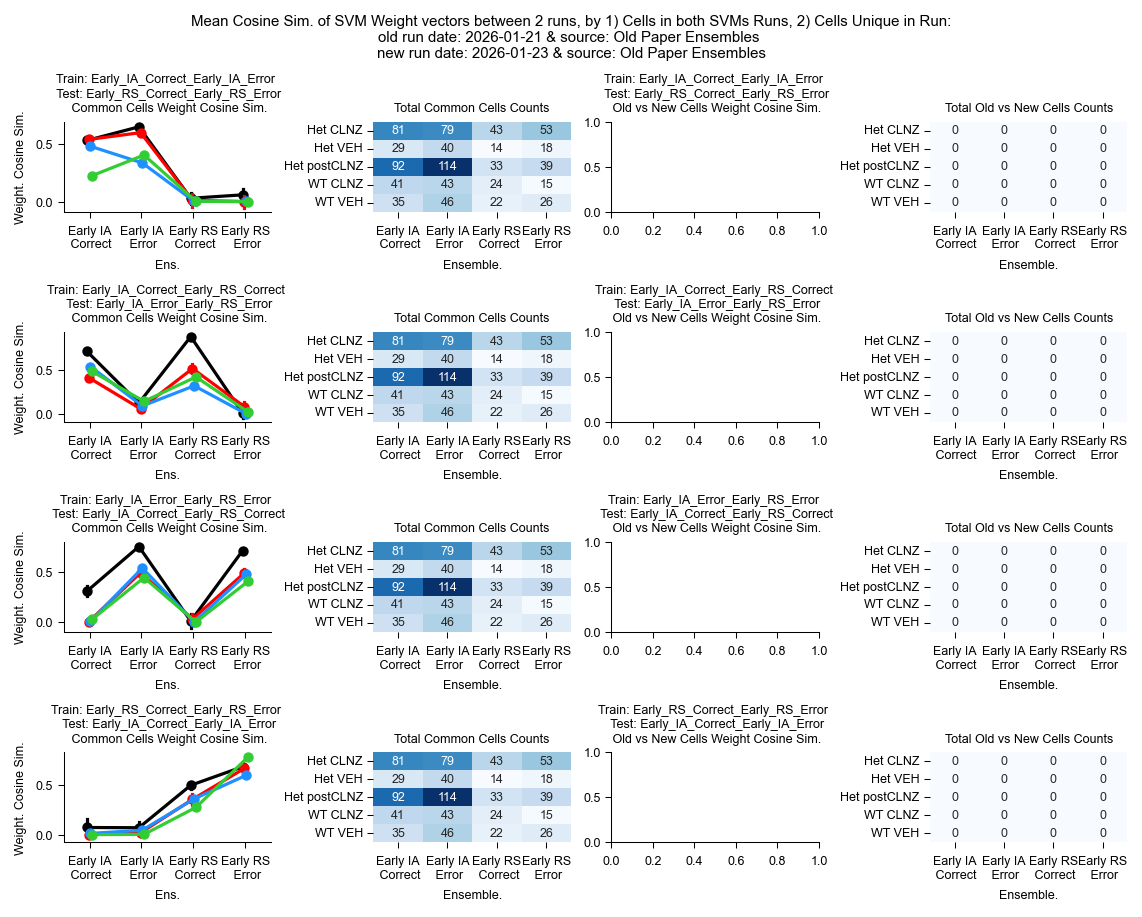

In [133]:
#facet through genotype days and ensembles to compare old vs new weight matrices, for each train_on and test_on condition, divided by common, old, and new
overlap_types = ['Common Cells', 'Old vs New Cells']
n_rows = len(corr_cell_dict.keys())
n_cols = len(overlap_types)*2

overlap_count_ax = {'Common Cells': 1, 'Old vs New Cells': 3}
overlap_point_ax = {'Common Cells': 0, 'Old vs New Cells': 2}
fig, ax_array = plt.subplots( nrows = n_rows, ncols=n_cols, layout = 'constrained',figsize=(7.5,6), sharey= False, width_ratios=[2.1,2,2.1,2])

for comp_count, (train_on, test_on) in enumerate(corr_cell_dict.keys()): #trainon-teston pairs
    print(train_on, test_on)
    print(corr_cell_dict[(train_on, test_on)].keys()) #geno_day, ensemble pairs
    cell_count_list, geno_ens_storage = [], []

    for geno_day, ens in corr_cell_dict[(train_on, test_on)].keys():
        # print(f"  {geno_day}, {ens}")
        cosine_matrix = corr_cell_dict[(train_on, test_on)][(geno_day, ens)]['cosine_matrix']
        common_cells = corr_cell_dict[(train_on, test_on)][(geno_day, ens)]['common_cells']
        old_only_cells = corr_cell_dict[(train_on, test_on)][(geno_day, ens)]['old_only_cells']
        new_only_cells = corr_cell_dict[(train_on, test_on)][(geno_day, ens)]['new_only_cells']
        
        # index into cosine matrix, get common cell only submatrix
        common_submatrix = cosine_matrix.loc[[c + '_old' for c in common_cells], [c + '_new' for c in common_cells]]
        common_cosine_vals = common_submatrix.reset_index().rename(columns={'index': 'old_cell_id'}).melt(id_vars=['old_cell_id'], var_name='new_cell_id', value_name='cosine_sim')
        common_cosine_vals['Cells_Compared']='Common Cells'
        
        #index into cosine matrix, get old only vs new only cell submatrix
        old_vs_new_submatrix = cosine_matrix.loc[[c + '_old' for c in old_only_cells], [c + '_new' for c in new_only_cells]]
        #melt submatrix to preserve cell IDs for old vs new
        old_vs_new_cosine_vals = old_vs_new_submatrix.reset_index().rename(columns={'index': 'old_cell_id'}).melt(id_vars=['old_cell_id'], var_name='new_cell_id', value_name='cosine_sim')
        old_vs_new_cosine_vals['Cells_Compared']='Old vs New Cells'
        all_cosine_sim = pd.concat([common_cosine_vals, old_vs_new_cosine_vals]).assign(geno_day=geno_day, 
                                                                                        ensemble=ens,
                                                                                         )
        
        geno_ens_storage.append(all_cosine_sim)
        ## store table  with cell counts:
        cell_count_list.append({'train_on': train_on, 'test_on': test_on,
                'geno_day': geno_day, 'ensemble': ens,
                'Common Cells': len(common_cells),
                'Old Only Cells': len(old_only_cells),
                'New Only Cells': len(new_only_cells),
                'Old vs New Cells': len(old_only_cells) + len(new_only_cells)}
                )
# plot common_cosine vals and old_vs_new cosine vals  as stripplots, each as a category on x axis
    all_cosine_sim = pd.concat(geno_ens_storage).reset_index(drop=True)
    cell_count_df = pd.DataFrame(cell_count_list)
    for o, overlap_type in enumerate(overlap_types):
        print(overlap_type)
        ax = ax_array[comp_count, overlap_point_ax[overlap_type]]
        subset = all_cosine_sim[all_cosine_sim.Cells_Compared == overlap_type]
        ax.set_title(f"Train: {train_on} \n Test: {test_on}\n {overlap_type} Weight Cosine Sim.")
        if len(subset) > 0:
            sns.pointplot(data=subset, ax=ax, x='ensemble', y='cosine_sim', dodge = True, order = early_stages,
                           **geno_color_dict)
            set_labels(ax = ax, label_dict= {'ylabel': 'Weight. Cosine Sim.', 'xlabel': 'Ens.'})
            ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) 
            ax.get_legend().remove()

        # in ax col 3, plot heatmap table of the # of common cells, old only cells, and new only cells
        ax = ax_array[comp_count, overlap_count_ax[overlap_type]]
        pivot_cell_count = cell_count_df[cell_count_df.ensemble.isin(early_stages)].pivot(index='geno_day', columns='ensemble', values=overlap_type)
        sns.heatmap(ax = ax, data= pivot_cell_count, annot = True, fmt='d', cmap='Blues', cbar=False)
        # pivot table for heatmap
        set_labels(ax = ax, label_dict= {'title': f"Total {overlap_type} Counts", 'ylabel': None,  'xlabel': 'Ensemble.'})
        ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()),rotation = 0)

#zoom out to main fig, add sup title
suptitle = [f"Mean Cosine Sim. of SVM Weight vectors between 2 runs, by 1) Cells in both SVMs Runs, 2) Cells Unique in Run:",
            f"old run date: {cell_old.run_end_date.iloc[0]} & source: {cell_old.dataset_label.iloc[0]} ",
            f"new run date: {cell_new.run_end_date.iloc[0]} & source: {cell_new.dataset_label.iloc[0]}"]
fig.suptitle('\n'.join(suptitle))
## save fig
fig_name = f"SVM_Weight_Cosine_Sim- {cell_old.dataset_label.iloc[0]} v {cell_new.dataset_label.iloc[0]} runs_{pd.Timestamp.now().strftime('%Y-%m-%d')}.png"
print(f" saving {fig_name}")
fig.savefig(results_loc_ccg_compare / fig_name, dpi=300)

In [134]:
cell_count_df[cell_count_df.ensemble.isin(early_stages)]

,train_on,test_on,geno_day,ensemble,Common Cells,Old Only Cells,New Only Cells,Old vs New Cells
0,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het CLNZ,Early_IA_Correct,81,0,0,0
1,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het CLNZ,Early_IA_Error,79,0,0,0
2,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het CLNZ,Early_RS_Correct,43,0,0,0
3,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het CLNZ,Early_RS_Error,53,0,0,0
4,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het VEH,Early_IA_Correct,29,0,0,0
5,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het VEH,Early_IA_Error,40,0,0,0
6,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het VEH,Early_RS_Correct,14,0,0,0
7,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het VEH,Early_RS_Error,18,0,0,0
8,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het postCLNZ,Early_IA_Correct,92,0,0,0
9,Early_RS_Correct_Early_RS_Error,Early_IA_Correct_Early_IA_Error,Het postCLNZ,Early_IA_Error,114,0,0,0


In [135]:
all_cosine_sim[all_cosine_sim.Cells_Compared== overlap_type]

,old_cell_id,new_cell_id,cosine_sim,Cells_Compared,geno_day,ensemble


Early_IA_Correct_Early_IA_Error Early_RS_Correct_Early_RS_Error
dict_keys([('Het CLNZ', 'Early_IA_Correct'), ('Het CLNZ', 'Early_IA_Error'), ('Het CLNZ', 'Early_RS_Correct'), ('Het CLNZ', 'Early_RS_Error'), ('Het VEH', 'Early_IA_Correct'), ('Het VEH', 'Early_IA_Error'), ('Het VEH', 'Early_RS_Correct'), ('Het VEH', 'Early_RS_Error'), ('Het postCLNZ', 'Early_IA_Correct'), ('Het postCLNZ', 'Early_IA_Error'), ('Het postCLNZ', 'Early_RS_Correct'), ('Het postCLNZ', 'Early_RS_Error'), ('WT CLNZ', 'Early_IA_Correct'), ('WT CLNZ', 'Early_IA_Error'), ('WT CLNZ', 'Early_RS_Correct'), ('WT CLNZ', 'Early_RS_Error'), ('WT VEH', 'Early_IA_Correct'), ('WT VEH', 'Early_IA_Error'), ('WT VEH', 'Early_RS_Correct'), ('WT VEH', 'Early_RS_Error')])
Early_IA_Correct_Early_RS_Correct Early_IA_Error_Early_RS_Error
dict_keys([('Het CLNZ', 'Early_IA_Correct'), ('Het CLNZ', 'Early_IA_Error'), ('Het CLNZ', 'Early_RS_Correct'), ('Het CLNZ', 'Early_RS_Error'), ('Het VEH', 'Early_IA_Correct'), ('Het VEH', 'Early_IA_Er

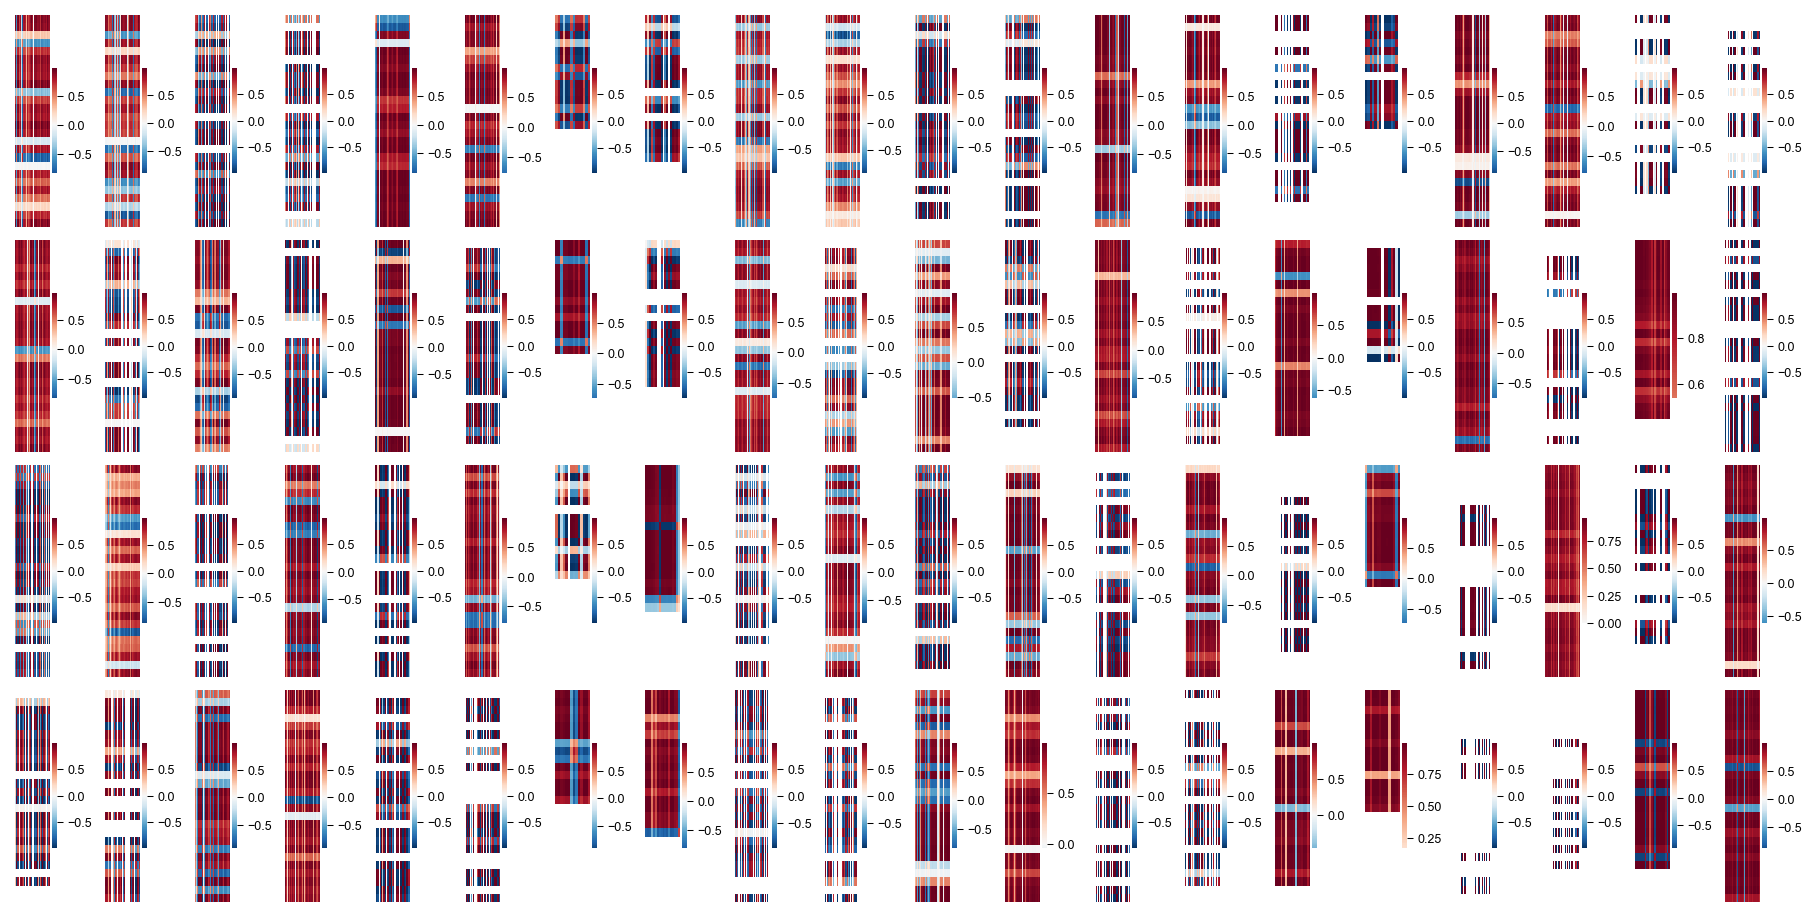

In [136]:
#are all the cosine matrices the same values?
n_rows = len(corr_cell_dict.keys())
n_cols = len(corr_cell_dict[(train_on, test_on)].keys())
fig, ax_array = plt.subplots( nrows = n_rows, ncols=n_cols, layout = 'constrained', sharey= True, figsize=(12,6 ))
for comp_count, (train_on, test_on) in enumerate(corr_cell_dict.keys()): #trainon-teston pairs
    print(train_on, test_on)
    print(corr_cell_dict[(train_on, test_on)].keys()) #geno_day, ensemble pairs
    geno_ens_storage = []
    for e, (geno_day, ens) in enumerate(corr_cell_dict[(train_on, test_on)].keys()):
        # print(f"  {geno_day}, {ens}")
        ax = ax_array[comp_count, e]
        cosine_matrix = corr_cell_dict[(train_on, test_on)][(geno_day, ens)]['cosine_matrix']
        sns.heatmap(cosine_matrix, ax=ax, cmap='RdBu_r', center=0, xticklabels = False, yticklabels=False)
        # set_labels(ax = ax, label_dict= {'title': f"{geno_day}, {ens}", 
                                        #  'ylabel': f"Old Run's Cell IDs",
                                            # 'xlabel': f"New Run's Cell IDs"})

In [137]:
all_cosine_sim

,old_cell_id,new_cell_id,cosine_sim,Cells_Compared,geno_day,ensemble
0,13_8_HET_RS2-127_old,13_8_HET_RS2-127_new,NaN,Common Cells,Het CLNZ,Early_IA_Correct
1,9_3_HET_RS2-131_old,13_8_HET_RS2-127_new,NaN,Common Cells,Het CLNZ,Early_IA_Correct
2,13_8_HET_RS2-136_old,13_8_HET_RS2-127_new,NaN,Common Cells,Het CLNZ,Early_IA_Correct
3,7_6_HET_RS2-5_old,13_8_HET_RS2-127_new,NaN,Common Cells,Het CLNZ,Early_IA_Correct
4,15_1_HET_RS2-52_old,13_8_HET_RS2-127_new,NaN,Common Cells,Het CLNZ,Early_IA_Correct
...,...,...,...,...,...,...
53318,5_3_WT_RS1-163_old,5_3_WT_RS1-107_new,0.838198,Common Cells,WT VEH,Early_RS_Error
53319,7_5_WT_RS1-25_old,5_3_WT_RS1-107_new,0.836193,Common Cells,WT VEH,Early_RS_Error
53320,7_5_WT_RS1-73_old,5_3_WT_RS1-107_new,0.822716,Common Cells,WT VEH,Early_RS_Error
53321,6_2_WT_RS1-31_old,5_3_WT_RS1-107_new,0.835998,Common Cells,WT VEH,Early_RS_Error


In [138]:
common_cosine_vals = common_submatrix.reset_index().rename(columns={'index': 'old_cell_id'}).melt(id_vars=['old_cell_id'], var_name='new_cell_id', value_name='cosine_sim')
common_cosine_vals['Cells_Compared']='Common Cells'
common_cosine_vals
#melt submatrix to preserve cell IDs for old vs new
old_vs_new_cosine_vals = old_vs_new_submatrix.reset_index().rename(columns={'index': 'old_cell_id'}).melt(id_vars=['old_cell_id'], var_name='new_cell_id', value_name='cosine_sim')
old_vs_new_cosine_vals['Cells_Compared']='Old vs New Cells'
all_cosine_sim = pd.concat([common_cosine_vals, old_vs_new_cosine_vals])
all_cosine_sim

,old_cell_id,new_cell_id,cosine_sim,Cells_Compared
0,7_5_WT_RS1-142_old,7_5_WT_RS1-142_new,0.933398,Common Cells
1,7_5_WT_RS1-157_old,7_5_WT_RS1-142_new,0.949308,Common Cells
2,7_5_WT_RS1-1_old,7_5_WT_RS1-142_new,0.943850,Common Cells
3,7_5_WT_RS1-60_old,7_5_WT_RS1-142_new,0.951504,Common Cells
4,5_3_WT_RS1-111_old,7_5_WT_RS1-142_new,0.939250,Common Cells
...,...,...,...,...
671,5_3_WT_RS1-163_old,5_3_WT_RS1-107_new,0.838198,Common Cells
672,7_5_WT_RS1-25_old,5_3_WT_RS1-107_new,0.836193,Common Cells
673,7_5_WT_RS1-73_old,5_3_WT_RS1-107_new,0.822716,Common Cells
674,6_2_WT_RS1-31_old,5_3_WT_RS1-107_new,0.835998,Common Cells


<Axes: >

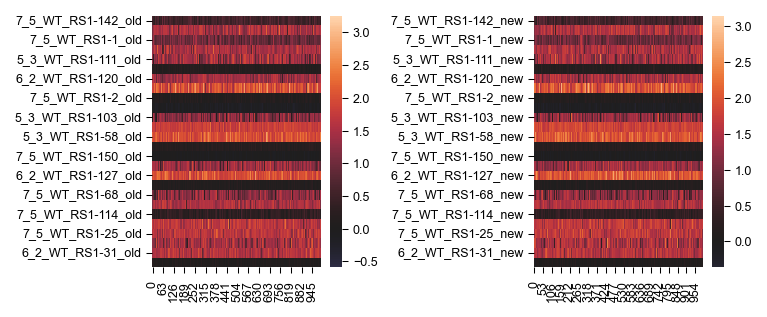

In [139]:
fig,axes = plt.subplots(1,2, figsize=(5,2), layout='constrained')
sns.heatmap(ax = axes[0], data= cell_old_weight_df.T, center = 0)
sns.heatmap(ax = axes[1], data= cell_weight_df.T, center = 0)

In [140]:
print(f"cell_weight_df sample: {cell_weight_df.sample()}")

cell_weight_df sample:      7_5_WT_RS1-142_new  7_5_WT_RS1-157_new  7_5_WT_RS1-1_new  \
321            0.735432            1.533694          0.634657   

     7_5_WT_RS1-60_new  5_3_WT_RS1-111_new  6_2_WT_RS1-112_new  \
321           1.418754             1.40033            0.129429   

     6_2_WT_RS1-120_new  7_5_WT_RS1-19_new  7_5_WT_RS1-2_new  \
321            1.526668           2.804267          0.111613   

     7_5_WT_RS1-40_new  ...  6_2_WT_RS1-127_new  7_5_WT_RS1-37_new  \
321          -0.123521  ...            1.963092           0.096779   

     7_5_WT_RS1-68_new  7_5_WT_RS1-134_new  7_5_WT_RS1-114_new  \
321           0.797154            1.646979            0.284242   

     5_3_WT_RS1-163_new  7_5_WT_RS1-25_new  7_5_WT_RS1-73_new  \
321            1.562949           1.620114           1.883988   

     6_2_WT_RS1-31_new  5_3_WT_RS1-107_new  
321           1.360386            0.087681  

[1 rows x 26 columns]


In [141]:
print(f"cell_old_weight_df sample: {cell_old_weight_df.sample()}")

cell_old_weight_df sample:     7_5_WT_RS1-142_old  7_5_WT_RS1-157_old  7_5_WT_RS1-1_old  \
11            0.441522            1.633572          0.813883   

    7_5_WT_RS1-60_old  5_3_WT_RS1-111_old  6_2_WT_RS1-112_old  \
11           1.455387            1.848997            0.184705   

    6_2_WT_RS1-120_old  7_5_WT_RS1-19_old  7_5_WT_RS1-2_old  \
11            1.273422           1.823834          0.135543   

    7_5_WT_RS1-40_old  ...  6_2_WT_RS1-127_old  7_5_WT_RS1-37_old  \
11          -0.101973  ...            2.517116            0.14479   

    7_5_WT_RS1-68_old  7_5_WT_RS1-134_old  7_5_WT_RS1-114_old  \
11           1.418486            1.708631            0.272336   

    5_3_WT_RS1-163_old  7_5_WT_RS1-25_old  7_5_WT_RS1-73_old  \
11            1.715014           1.850458           1.525471   

    6_2_WT_RS1-31_old  5_3_WT_RS1-107_old  
11           1.841241            0.112196  

[1 rows x 26 columns]


In [ ]:
cell_presence_overlap = pd.DataFrame.from_records(merged_weight_overlap)
# Calculate percentage
cell_presence_overlap['pct_overlap'] = cell_presence_overlap['n_overlap'] / cell_presence_overlap['n_new_ids'] * 100

# Create train_test pair for faceting
cell_presence_overlap['train_test'] = 'Train on: ' + cell_presence_overlap['train_on'] + 'Test on: ' + cell_presence_overlap['test_on']
cell_presence_overlap

In [ ]:
train_tests = cell_presence_overlap['train_test'].unique()
fig, axes = plt.subplots(1, len(train_tests), figsize=(2.4 * len(train_tests), 2),layout = 'constrained', sharey=True)

for t_val, tt in enumerate(train_tests):
    print(tt)
    subset =     subset = cell_presence_overlap[cell_presence_overlap['train_test'] == tt]

    print(subset.tail())
    sns.barplot(data=subset, x='ensemble', y='pct_overlap', ax=axes[t_val], **geno_color_dict_no_errorbar)
    set_labels(ax=axes[t_val], label_dict={'title': tt,
                                  'xlabel': 'Ensemble',
                                 'ylabel': r'% of New Ens. in old Ens.' if ax == axes[0] else ''})



In [ ]:
# Check if actual cell_id SETS vary by train_on/test_on
sample = decode_out_weights.query("ensemble == 'Early_IA_Correct' and geno_day == 'Het CLNZ'")
cell_id_sets = sample.groupby(['train_on', 'test_on'])['cell_ids'].apply(lambda x: tuple(sorted(x.iloc[0])))
print(cell_id_sets)
print(f"Unique cell_id sets: {cell_id_sets.nunique()} out of {len(cell_id_sets)} train_test combos")

In [ ]:
cell_presence_overlap[cell_presence_overlap['train_test'] == train_tests[0]].head()


In [ ]:
cell_presence_overlap[cell_presence_overlap['train_test'] == train_tests[1]].head()

In [ ]:
old_v_new_corr

In [ ]:
# #get list of old Ids and new IDs:
            # old_base_ids = cell_old_weight_df.columns
            # new_base_ids = cell_weight_df.columns
            # #find common cell Ids
            # common = [c for c in old_base_ids if c in new_base_ids]
            # only_old = [c for c in old_base_ids if c not in new_base_ids]
            # only_new = [c for c in new_base_ids if c not in old_base_ids]
            # #use this to make new order

            # #rename df columns to guarantee no overlap
            # new_cell_order  = [str(c) + '_new' for c in common + only_new]
            # old_cell_order = [str(c) + '_old' for c in common + only_old]
            # #merge old and new on ids to get cell_ids_old, and cell_ids_new cols
            
            # merged_cells = pd.merge(cell_weight_df, cell_old_weight_df, left_index=True, right_index=True, suffixes=('_new', '_old'))
            # corr_merged_df   = merged_cells.corr()
            # #use old cell Ids to select indices
            # old_cell_ids = cell_old_weight_df.columns 
            # new_cell_ids = cell_weight_df.columns

            # #old v new cell weight correlation heatmap
            # old_v_new_corr = corr_merged_df.loc[old_cell_ids, new_cell_ids]

In [ ]:
merged_cells.info()

In [ ]:
merged_cells


In [ ]:

sns.heatmap(old_v_new_corr)

#### viz activity of cells used to decode in task stages

In [ ]:
# Import parquet
cell_activity_filename = "Cell Activity (Out of Distrib) 1000 pseudopop post_outcome_activity 22_Jan_2026.parquet"
cell_activity_date = cell_activity_filename.split('activity ')[1].replace('.parquet', '')
print(f"Loading cell activity data from run date: {cell_activity_date}")
cell_activity_df = pd.read_parquet(run_record_loc / Path(cell_activity_filename))

In [ ]:
cell_activity_df.head()

In [ ]:
# Aggregate across runs
agg_df = cell_activity_df.groupby(['ensemble', 'geno_day', 'train_on', 'test_on']).agg(
    cell_ids=('cell_ids', 'first'),
    c0_train_mean=('c0_train_mean', lambda x: np.vstack(x).mean(axis=0)),
    c1_train_mean=('c1_train_mean', lambda x: np.vstack(x).mean(axis=0)),
    c0_test_mean=('c0_test_mean', lambda x: np.vstack(x).mean(axis=0)),
    c1_test_mean=('c1_test_mean', lambda x: np.vstack(x).mean(axis=0)),
).reset_index()

# Plot settings
row = 'geno_day'
col = 'ensemble'

for (train_on, test_on), subset in agg_df.groupby(['train_on', 'test_on']):
    row_vals, col_vals = subset[row].unique(), subset[col].unique()

    fig, axes = plt.subplots(len(row_vals), len(col_vals), layout = 'constrained',figsize=(1.1*len(col_vals), 0.8*len(row_vals)))
    
    for (rv, cv), ax in zip(product(row_vals, col_vals), axes.flat):
        cell_data = subset[(subset[row] == rv) & (subset[col] == cv)]
        
        if len(cell_data) == 1:
            row_data = cell_data.iloc[0]
            # Build matrix: rows=cells, cols=classes
            activity_matrix = np.column_stack([
                row_data['c0_train_mean'],
                row_data['c1_train_mean'],
                row_data['c0_test_mean'],
                row_data['c1_test_mean']
            ])
            
            activity_heatmap_df = pd.DataFrame(activity_matrix,index=row_data['cell_ids'],columns=['Train C0', 'Train C1', 'Test C0', 'Test C1']).T
            sns.heatmap(activity_heatmap_df, ax=ax, cmap='viridis', cbar=cv==col_vals[-1],
                        xticklabels=False, yticklabels= cv == col_vals[0])
            ax.set_title(f"{cv} ens \n(decoded w. {activity_heatmap_df.shape[1]} cells)")
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        if cv == col_vals[0]:
            ax.set_ylabel(rv)
    fig.suptitle(f"Activity of Ensemble Cells used in CCGP SVM (from {cell_activity_date}) \n Train on: {train_on} stage activity | Test on: {test_on}",)